In [ ]:
%pip install "bayesian-optimization==3.3.0"
%pip install "hyperopt==0.3.0"
%pip install "ConfigSpace==1.2.2"
%pip install "smac==2.4.0"

import time
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import ExpectedImprovement
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import itertools
import re
import pandas as pd
from IPython.display import FileLink, display



## Patient response function and Bayesian optimzer algorithm functions.

In [ ]:
import pandas as pd
import numpy as np
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario

# Here are many different families of patients.

baseline_family = {
    'name': 'quick_rise_slow_fall',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

symmetric_family = {
    'name': 'symmetric',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'symmetric',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

slow_rise_quick_fall_family = {
    'name': 'slow_rise_quick_fall',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'slow_rise_quick_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

three_optima_family = {
    'name': '3optima',
    'num_optima': 3,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

broad_peaks_family = {
    'name': 'broad_optima',
    'num_optima': 2,
    'spread_scale': 2.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

sharp_peaks_family = {
    'name': 'sharp_optima',
    'num_optima': 2,
    'spread_scale': 0.4,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

heteroscedastic_noise_family = {
    'name': 'heteroscedastic_noise',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'heteroscedastic',
    'unique_parameter_interaction': 'none'
}

heavy_tailed_noise_family = {
    'name': 'heavy_tailed_noise',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'heavy_tailed',
    'unique_parameter_interaction': 'none'
}

unique_parameter_interaction_family = {
    'name': 'unique_parameter_interaction',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'pulsewidth-amplitude'
}


def asymmetric_hill_peak(
    value,
    optimum,
    left_scale,
    right_scale,
    hill_n=4.0,
):
    """Return a Hill-like peak anchored at an explicit optimum."""
    if left_scale <= 0 or right_scale <= 0 or hill_n <= 0:
        raise ValueError("Scales and hill_n must be positive.")

    value = np.asarray(value, dtype=float)
    scale = np.where(value < optimum, left_scale, right_scale)
    distance = np.abs(value - optimum) / scale

    return 1.0 / (1.0 + distance**hill_n)


def generate_patient_profile(patient_seed: int, family: dict):
    """Draws one unique synthetic patient's response landscape for a given surface family, independent of any optimizer's own RNG."""
    rng = np.random.default_rng(patient_seed)

    base_optima = [(10.0 + rng.uniform(-2.0, 2.0), 500.0 + rng.uniform(-25.0, 25.0)),
                   (25.0 + rng.uniform(-2.0, 2.0), 100.0 + rng.uniform(-25.0, 25.0))] #may need to change this later on.
    num_optima = family['num_optima']
    optima = []
    for numOfOptima in range(num_optima):
        if numOfOptima < len(base_optima):
            opt_f, opt_w = base_optima[numOfOptima]
        else:
            opt_f = rng.uniform(5.0, 50.0)
            opt_w = rng.uniform(150.0, 450.0)
        optima.append((opt_f, opt_w))

    spread_scale = family['spread_scale']

    if family['function_shape'] == 'quick_rise_slow_fall':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Asymmetric spreads: faster rise toward threshold, slower decline above it
            'amp_rise_pup': rng.uniform(0.25, 0.35) * spread_scale,
            'amp_fall_pup': rng.uniform(0.55, 0.75) * spread_scale,
            'amp_rise_hrv': rng.uniform(0.20, 0.30) * spread_scale,
            'amp_fall_hrv': rng.uniform(0.45, 0.65) * spread_scale,

            'freq_rise': rng.uniform(1.0, 2.0) * spread_scale,
            'freq_fall': rng.uniform(5.0, 6.0) * spread_scale,
            'pulse_width_rise': rng.uniform(20.0, 50.0) * spread_scale,
            'pulse_width_fall': rng.uniform(125.0, 175.0) * spread_scale,

            'optima': optima,
        }
    elif family['function_shape'] == 'symmetric':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Symmetric spreads: same rise and fall
            'amp_rise_pup': 0.25,
            'amp_fall_pup': 0.25,
            'amp_rise_hrv': 0.25,
            'amp_fall_hrv': 0.25,
            'freq_rise': 1.5,
            'freq_fall': 1.5,
            'pulse_width_rise': 35.0,
            'pulse_width_fall': 150.0,

            'optima': optima,
        }
    elif family['function_shape'] == 'slow_rise_quick_fall':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Asymmetric spreads: slower rise toward threshold, faster decline above it
            'amp_rise_pup': rng.uniform(0.55, 0.75) * spread_scale,
            'amp_fall_pup': rng.uniform(0.25, 0.35) * spread_scale,
            'amp_rise_hrv': rng.uniform(0.45, 0.65) * spread_scale,
            'amp_fall_hrv': rng.uniform(0.20, 0.30) * spread_scale,

            'freq_rise': rng.uniform(5.0, 6.0) * spread_scale,
            'freq_fall': rng.uniform(1.0, 2.0) * spread_scale,
            'pulse_width_rise': rng.uniform(125.0, 175.0) * spread_scale,
            'pulse_width_fall': rng.uniform(20.0, 50.0) * spread_scale,

            'optima': optima,
        }


def run_optimization_comparison(num_simulation_trials: int, amount_of_patients: int, patient_and_machine_startSeed : int, patient_type: dict):

    search_boundaries = {
        'amplitude': (0.5, 5.0),       # mA
        'frequency': (1.0, 50.0),      # Hz
        'pulse_width': (50.0, 600.0),  # microseconds
    }

    all_patients_results = []  # accumulates each patient's comparison_data across the loop
    all_convergence_results = []

    for i in range(amount_of_patients):

        patient_profile = generate_patient_profile(patient_and_machine_startSeed, patient_type)
        ideal_amp_pup = patient_profile['ideal_amp_pup']
        amp_rise_pup = patient_profile['amp_rise_pup']
        amp_fall_pup = patient_profile['amp_fall_pup']
        ideal_amp_hrv = patient_profile['ideal_amp_hrv']
        amp_rise_hrv = patient_profile['amp_rise_hrv']
        amp_fall_hrv = patient_profile['amp_fall_hrv']
        freq_rise = patient_profile['freq_rise']
        freq_fall = patient_profile['freq_fall']
        pulse_width_rise = patient_profile['pulse_width_rise']
        pulse_width_fall = patient_profile['pulse_width_fall']
        optima = patient_profile['optima']

        def realistic_patient_curve(amplitude, frequency, pulse_width, AddNoise: bool, patient_and_machine_startSeed: int):

            # Pupillometry Calculation (anchored asymmetric Hill peaks)
            amp_comp_pup = asymmetric_hill_peak(
                amplitude,
                ideal_amp_pup,
                amp_rise_pup,
                amp_fall_pup,
            )
            amp_comp_hrv = asymmetric_hill_peak(
                amplitude,
                ideal_amp_hrv,
                amp_rise_hrv,
                amp_fall_hrv,
            )

            pup_score = 100 * amp_comp_pup
            hrv_score = 100 * amp_comp_hrv
            w_pup, w_hrv = 0.5, 0.5
            amplitude_score = w_pup * pup_score + w_hrv * hrv_score

            # We calculate response based on proximity to the optimal (Freq, Width) pairs
            def get_interdependence_score(f, w, Amplitude_Scale_Factor = 1.0):
                scores = []
                for (opt_f, opt_w) in optima:
                    freq_comp = asymmetric_hill_peak(
                        f,
                        opt_f,
                        freq_rise,
                        freq_fall,
                    )
                    width_comp = asymmetric_hill_peak(
                        w,
                        opt_w,
                        pulse_width_rise,
                        pulse_width_fall,
                    )
                    dist = ((freq_comp) * (width_comp)) * Amplitude_Scale_Factor
                    scores.append(dist)

                return np.max(np.asarray(scores), axis=0)

            if patient_type.get('unique_parameter_interaction') == 'pulsewidth-amplitude':
                inter_score = get_interdependence_score(frequency, pulse_width, amplitude_score/100)
            else:
                inter_score = get_interdependence_score(frequency, pulse_width)

            total_score = inter_score * amplitude_score

            if not AddNoise:
                return total_score

            rng = np.random.default_rng(patient_and_machine_startSeed)
            noise_type = patient_type.get('noise', 'normal')
            if noise_type == 'normal':
                noise = rng.normal(0, 2.0)  # e.g., standard deviation of 2.0
            elif noise_type == 'heteroscedastic':
                    # Noise scales with signal magnitude
                noise = rng.normal(0, 0.05 * amplitude_score)
            elif noise_type == 'heavy_tailed':
                    # Student's t-distribution
                noise = rng.standard_t(df=3) * 2.0
            else:
                noise = 0.0

            total_score += noise

            return total_score

        #Find the optimal score and parameters
        amplitude_grid = np.linspace(search_boundaries['amplitude'][0], search_boundaries['amplitude'][1], 10000)

        max_possible_score = -np.inf

        for (opt_f, opt_w) in optima:
            # Vectorized evaluation over the amplitude grid at the peak frequency & pulse width
            curve_scores = realistic_patient_curve(amplitude_grid, opt_f, opt_w, False, 0)
            best_idx = np.argmax(curve_scores)
            peak_score = curve_scores[best_idx]

            if peak_score > max_possible_score:
                max_possible_score = peak_score

        method_names = (
            "Bayesian Optimization",
            "TPE Optimization",
            "SMAC Optimization",
            "Random Search",
        )

        def make_evaluation_seed(profile_seed, query_index):
            sequence = np.random.SeedSequence(
                [int(profile_seed), int(query_index)]
            )
            return int(sequence.generate_state(1, dtype=np.uint32)[0])

        profile_seed = patient_and_machine_startSeed
        convergence_rows = []

        query_counts = {
            method: 0
            for method in method_names
        }

        best_observed = {
            method: -np.inf
            for method in method_names
        }

        best_noise_free = {
            method: -np.inf
            for method in method_names
        }

        incumbent_noise_free = {
            method: np.nan
            for method in method_names
        }

        def evaluate_and_record(method, params, evaluation_seed):
            query_index = query_counts[method] + 1
            query_counts[method] = query_index

            observed_score = realistic_patient_curve(
                params["amplitude"],
                params["frequency"],
                params["pulse_width"],
                True,
                evaluation_seed,
            )

            noise_free_score = realistic_patient_curve(
                params["amplitude"],
                params["frequency"],
                params["pulse_width"],
                False,
                evaluation_seed,
            )

            is_new_observed_best = observed_score > best_observed[method]

            best_observed[method] = max(
                best_observed[method],
                observed_score,
            )

            best_noise_free[method] = max(
                best_noise_free[method],
                noise_free_score,
            )

            if is_new_observed_best:
                incumbent_noise_free[method] = noise_free_score

            convergence_rows.append({
                "Profile ID": (
                    f"{patient_profile['surface_family']}::{profile_seed}"
                ),
                "Surface Family": patient_profile["surface_family"],
                "Profile Seed": profile_seed,
                "Iteration Budget": num_simulation_trials,
                "Method": method,
                "Query": query_index,
                "Evaluation Seed": evaluation_seed,
                "Amplitude": params["amplitude"],
                "Frequency": params["frequency"],
                "Pulse Width": params["pulse_width"],
                "Observed Score": observed_score,
                "Noise-Free Score": noise_free_score,
                "Cumulative Best Observed Score": best_observed[method],
                "Best Noise-Free Score So Far": best_noise_free[method],
                "Current Incumbent Noise-Free Score": incumbent_noise_free[method],
                "Normalized Regret So Far (%)": (
                    100
                    * (
                        max_possible_score
                        - best_noise_free[method]
                    )
                    / max_possible_score
                ),
            })

            return observed_score

        def objective_bo(amplitude, frequency, pulse_width):
            query_index = (
                query_counts["Bayesian Optimization"] + 1
            )
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            return evaluate_and_record(
                "Bayesian Optimization",
                {
                    "amplitude": amplitude,
                    "frequency": frequency,
                    "pulse_width": pulse_width,
                },
                evaluation_seed,
            )

        optimizer_multi = BayesianOptimization(
            f=objective_bo,
            pbounds=search_boundaries,
            acquisition_function=ExpectedImprovement(xi=0.01),
            random_state=patient_and_machine_startSeed,
            verbose=0
        )
        print(f"\n--- Starting Bayesian Optimization ({num_simulation_trials} iterations) ---")
        bo_start_time = time.perf_counter()
        optimizer_multi.maximize(init_points=4, n_iter=num_simulation_trials - 4)

        bo_elapsed_seconds = time.perf_counter() - bo_start_time
        print(f"Bayesian Optimization completed in {bo_elapsed_seconds:.3f} seconds.")

        # --- TPE Optimization ---
        tpe_start_time = time.perf_counter()
        def objective_tpe(params):
            query_index = query_counts["TPE Optimization"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            score = evaluate_and_record(
                "TPE Optimization",
                {
                    "amplitude": params["amplitude"],
                    "frequency": params["frequency"],
                    "pulse_width": params["pulse_width"],
                },
                evaluation_seed,
            )

            return {
                "loss": -score,
                "status": STATUS_OK,
            }
        space = {
            'amplitude': hp.uniform('amplitude', search_boundaries['amplitude'][0], search_boundaries['amplitude'][1]),
            'frequency': hp.uniform('frequency', search_boundaries['frequency'][0], search_boundaries['frequency'][1]),
            'pulse_width': hp.uniform('pulse_width', search_boundaries['pulse_width'][0], search_boundaries['pulse_width'][1])
        }
        trials = Trials()
        print(f"\n--- Starting TPE Optimization ({num_simulation_trials} iterations) ---")
        fmin(fn=objective_tpe, space=space, algo=tpe.suggest, max_evals=num_simulation_trials, trials=trials, rstate=np.random.default_rng(patient_and_machine_startSeed))
        tpe_elapsed_seconds = time.perf_counter() - tpe_start_time
        print(f"TPE completed in {tpe_elapsed_seconds:.3f} seconds.")

        # --- SMAC Optimization ---
        smac_start_time = time.perf_counter()
        configspace = ConfigurationSpace(seed=patient_and_machine_startSeed)
        configspace.add([
            Float('amplitude', bounds=search_boundaries['amplitude']),
            Float('frequency', bounds=search_boundaries['frequency']),
            Float('pulse_width', bounds=search_boundaries['pulse_width']),
        ])

        def objective_smac(config, seed=None):
            query_index = query_counts["SMAC Optimization"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )
            score = evaluate_and_record(
                "SMAC Optimization",
                {
                    "amplitude": float(config["amplitude"]),
                    "frequency": float(config["frequency"]),
                    "pulse_width": float(config["pulse_width"]),
                },
                evaluation_seed,
            )

            return -score

        print(f"\n--- Starting SMAC Optimization ({num_simulation_trials} iterations) ---")
        scenario = Scenario(
            configspace,
            deterministic=False,
            n_trials=num_simulation_trials,
            seed=patient_and_machine_startSeed,
        )
        smac = HyperparameterOptimizationFacade(scenario, objective_smac)
        incumbent = smac.optimize()
        smac_score = -smac.runhistory.get_cost(incumbent)

        smac_elapsed_seconds = time.perf_counter() - smac_start_time
        print(f"SMAC completed in {smac_elapsed_seconds:.3f} seconds.")

        # --- Random Search ---
        rs_start_time = time.perf_counter()
        random_search_rng = np.random.default_rng(patient_and_machine_startSeed)
        best_random_score = -np.inf
        best_random_params = {}
        print(f"\n--- Starting Random Search Optimization ({num_simulation_trials} iterations) ---")
        for _ in range(num_simulation_trials):
            a, f, w = [
                random_search_rng.uniform(
                    search_boundaries[key][0],
                    search_boundaries[key][1],
                )
                for key in [
                    "amplitude",
                    "frequency",
                    "pulse_width",
                ]
            ]

            query_index = query_counts["Random Search"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            current_score = evaluate_and_record(
                "Random Search",
                {
                    "amplitude": a,
                    "frequency": f,
                    "pulse_width": w,
                },
                evaluation_seed,
            )

            if current_score > best_random_score:
                best_random_score = current_score
                best_random_params = {
                    "amplitude": a,
                    "frequency": f,
                    "pulse_width": w,
                }

        rs_elapsed_seconds = time.perf_counter() - rs_start_time
        print(f"Random Search completed in {rs_elapsed_seconds:.3f} seconds.")

        selected_scores_noise_free = [
            realistic_patient_curve(
                optimizer_multi.max['params']['amplitude'],
                optimizer_multi.max['params']['frequency'],
                optimizer_multi.max['params']['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                trials.argmin['amplitude'],
                trials.argmin['frequency'],
                trials.argmin['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                float(incumbent['amplitude']),
                float(incumbent['frequency']),
                float(incumbent['pulse_width']),
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                best_random_params['amplitude'],
                best_random_params['frequency'],
                best_random_params['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
        ]

        simple_regrets = [
            max_possible_score - score
            for score in selected_scores_noise_free
        ]

        normalized_regrets = [
            regret / max_possible_score
            if max_possible_score > 0
            else np.nan
            for regret in simple_regrets
        ]

        comparison_data = {
            'Method': ['Bayesian Optimization', 'TPE Optimization', 'SMAC Optimization', 'Random Search'],
            'Surface Family': [patient_profile['surface_family']] * 4,
            'Seed': [patient_and_machine_startSeed] * 4,
            'Best Possible Score': [max_possible_score] * 4,
            'Best Computed Score': [optimizer_multi.max['target'], -trials.best_trial['result']['loss'], smac_score, best_random_score],
            'Selected Amplitude (mA)': [optimizer_multi.max['params']['amplitude'], trials.argmin['amplitude'], float(incumbent['amplitude']), best_random_params['amplitude']],
            'Selected Frequency (Hz)': [optimizer_multi.max['params']['frequency'], trials.argmin['frequency'], float(incumbent['frequency']), best_random_params['frequency']],
            'Selected Pulse Width (us)': [optimizer_multi.max['params']['pulse_width'], trials.argmin['pulse_width'], float(incumbent['pulse_width']), best_random_params['pulse_width']],

            'Selected Score (Noise-Free)': selected_scores_noise_free,
            'Simple Regret': simple_regrets,
            #Gives percentage regret just in case
            'Normalized Regret (%)': [
                                100 * regret
                                for regret in normalized_regrets
                            ],
            'Sec To Compute': [bo_elapsed_seconds, tpe_elapsed_seconds, smac_elapsed_seconds, rs_elapsed_seconds]
        }

        all_patients_results.append(pd.DataFrame(comparison_data))
        all_convergence_results.append(
            pd.DataFrame(convergence_rows)
        )

        patient_and_machine_startSeed += 1

    return all_patients_results, all_convergence_results

ModuleNotFoundError: No module named 'bayes_opt'

In [ ]:
import importlib.metadata as importlib_metadata
from functools import partial
from pprint import pprint

from sklearn.gaussian_process.kernels import Matern


BOGP_DEFAULTS = {
    "acquisition_function": "ExpectedImprovement",
    "xi": 0.01,
    "exploration_decay": None,
    "exploration_decay_delay": None,
    "acquisition_random_state": None,
    "gp_kernel": "Matern(length_scale=1.0, nu=2.5)",
    "gp_alpha": 1e-6,
    "gp_normalize_y": True,
    "gp_n_restarts_optimizer": 5,
    "gp_optimizer": "fmin_l_bfgs_b",
    "init_points_rule": "4",
    "n_iter_rule": "num_simulation_trials - init_points",
    "random_state": "patient_and_machine_startSeed",
    "verbose": 0,
    "allow_duplicate_points": False,
}

TPE_DEFAULTS = {
    "prior_weight": 1.0,
    "n_startup_jobs": 20,
    "n_EI_candidates": 24,
    "gamma": 0.25,
    "suggest_verbose": True,
    "fmin_verbose": True,
    "show_progressbar": True,
    "max_queue_len": 1,
    "return_argmin": True,
    "allow_trials_fmin": True,
    "rstate": "np.random.default_rng(patient_and_machine_startSeed)",
}

SMAC_DEFAULTS = {
    "scenario": {
        "deterministic": False,
        "objectives": "cost",
        "use_default_config": False,
        "n_workers": 1,
        "n_trials": "num_simulation_trials",
        "seed": "patient_and_machine_startSeed",
    },
    "model": {
        "type": "RandomForest",
        "n_trees": 10,
        "ratio_features": 1.0,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_depth": 1048576,
        "bootstrapping": True,
    },
    "acquisition_function": {
        "type": "Expected Improvement",
        "xi": 0.0,
    },
    "initial_design": {
        "type": "SobolInitialDesign",
        "n_configs": None,
        "n_configs_per_hyperparameter": 10,
        "max_ratio": 0.25,
        "additional_configs": None,
    },
    "random_design": {
        "type": "ProbabilityRandomDesign",
        "probability": 0.2,
    },
    "intensifier": {
        "type": "Intensifier",
        "max_config_calls": 3,
        "max_incumbents": 10,
    },
    "config_selector": {
        "retrain_after": 8,
        "retries": 16,
    },
}

RANDOM_SEARCH_DEFAULTS = {
    "distribution": "independent Uniform(low, high) per parameter",
    "bounds": {
        "amplitude": (0.5, 5.0),
        "frequency": (1.0, 50.0),
        "pulse_width": (50.0, 600.0),
    },
    "sampling": "one independent draw for each parameter at every query",
    "replacement": True,
    "generator": "np.random.default_rng",
    "seed": "patient_and_machine_startSeed",
    "query_budget": "num_simulation_trials",
}

OPTIMIZER_PACKAGE_VERSIONS = {
    package_name: importlib_metadata.version(package_name)
    for package_name in (
        "bayesian-optimization",
        "hyperopt",
        "ConfigSpace",
        "smac",
    )
}


if "_original_bayesian_optimization" not in globals():
    _original_bayesian_optimization = BayesianOptimization


class ConfiguredBayesianOptimization(_original_bayesian_optimization):
    def __init__(self, *args, **kwargs):
        kwargs.setdefault(
            "allow_duplicate_points",
            BOGP_DEFAULTS["allow_duplicate_points"],
        )
        super().__init__(*args, **kwargs)
        self.set_gp_params(
            kernel=Matern(length_scale=1.0, nu=2.5),
            alpha=BOGP_DEFAULTS["gp_alpha"],
            normalize_y=BOGP_DEFAULTS["gp_normalize_y"],
            n_restarts_optimizer=BOGP_DEFAULTS["gp_n_restarts_optimizer"],
            optimizer=BOGP_DEFAULTS["gp_optimizer"],
        )


BayesianOptimization = ConfiguredBayesianOptimization


if "_original_tpe_suggest" not in globals():
    _original_tpe_suggest = tpe.suggest

tpe.suggest = partial(
    _original_tpe_suggest,
    prior_weight=TPE_DEFAULTS["prior_weight"],
    n_startup_jobs=TPE_DEFAULTS["n_startup_jobs"],
    n_EI_candidates=TPE_DEFAULTS["n_EI_candidates"],
    gamma=TPE_DEFAULTS["gamma"],
    verbose=TPE_DEFAULTS["suggest_verbose"],
)


if "_original_hyperopt_fmin" not in globals():
    _original_hyperopt_fmin = fmin


def configured_hyperopt_fmin(*args, **kwargs):
    kwargs.setdefault("verbose", TPE_DEFAULTS["fmin_verbose"])
    kwargs.setdefault("show_progressbar", TPE_DEFAULTS["show_progressbar"])
    kwargs.setdefault("max_queue_len", TPE_DEFAULTS["max_queue_len"])
    kwargs.setdefault("return_argmin", TPE_DEFAULTS["return_argmin"])
    kwargs.setdefault("allow_trials_fmin", TPE_DEFAULTS["allow_trials_fmin"])
    return _original_hyperopt_fmin(*args, **kwargs)


fmin = configured_hyperopt_fmin


if "_original_smac_facade" not in globals():
    _original_smac_facade = HyperparameterOptimizationFacade


class ConfiguredSMACFacade(_original_smac_facade):
    def __init__(self, scenario, target_function=None, **kwargs):
        kwargs.setdefault(
            "model",
            _original_smac_facade.get_model(
                scenario,
                n_trees=SMAC_DEFAULTS["model"]["n_trees"],
                ratio_features=SMAC_DEFAULTS["model"]["ratio_features"],
                min_samples_split=SMAC_DEFAULTS["model"]["min_samples_split"],
                min_samples_leaf=SMAC_DEFAULTS["model"]["min_samples_leaf"],
                max_depth=SMAC_DEFAULTS["model"]["max_depth"],
                bootstrapping=SMAC_DEFAULTS["model"]["bootstrapping"],
            ),
        )
        kwargs.setdefault(
            "acquisition_function",
            _original_smac_facade.get_acquisition_function(
                scenario,
                xi=SMAC_DEFAULTS["acquisition_function"]["xi"],
            ),
        )
        kwargs.setdefault(
            "initial_design",
            _original_smac_facade.get_initial_design(
                scenario,
                n_configs=SMAC_DEFAULTS["initial_design"]["n_configs"],
                n_configs_per_hyperparameter=SMAC_DEFAULTS["initial_design"][
                    "n_configs_per_hyperparameter"
                ],
                max_ratio=SMAC_DEFAULTS["initial_design"]["max_ratio"],
                additional_configs=SMAC_DEFAULTS["initial_design"][
                    "additional_configs"
                ],
            ),
        )
        kwargs.setdefault(
            "random_design",
            _original_smac_facade.get_random_design(
                scenario,
                probability=SMAC_DEFAULTS["random_design"]["probability"],
            ),
        )
        kwargs.setdefault(
            "intensifier",
            _original_smac_facade.get_intensifier(
                scenario,
                max_config_calls=SMAC_DEFAULTS["intensifier"]["max_config_calls"],
                max_incumbents=SMAC_DEFAULTS["intensifier"]["max_incumbents"],
            ),
        )
        kwargs.setdefault(
            "config_selector",
            _original_smac_facade.get_config_selector(
                scenario,
                retrain_after=SMAC_DEFAULTS["config_selector"]["retrain_after"],
                retries=SMAC_DEFAULTS["config_selector"]["retries"],
            ),
        )
        super().__init__(scenario, target_function, **kwargs)


HyperparameterOptimizationFacade = ConfiguredSMACFacade


print("Explicit optimizer configuration applied.")
print("Installed optimizer package versions:")
pprint(OPTIMIZER_PACKAGE_VERSIONS)
print("\nBOGP defaults:")
pprint(BOGP_DEFAULTS)
print("\nTPE defaults:")
pprint(TPE_DEFAULTS)
print("\nSMAC defaults:")
pprint(SMAC_DEFAULTS)
print("\nRandom Search defaults:")
pprint(RANDOM_SEARCH_DEFAULTS)

Explicit optimizer configuration applied.
Installed optimizer package versions:
{'ConfigSpace': '1.2.2',
 'bayesian-optimization': '3.3.0',
 'hyperopt': '0.3.0',
 'smac': '2.4.0'}

BOGP defaults:
{'acquisition_function': 'ExpectedImprovement',
 'acquisition_random_state': None,
 'allow_duplicate_points': False,
 'exploration_decay': None,
 'exploration_decay_delay': None,
 'gp_alpha': 1e-06,
 'gp_kernel': 'Matern(length_scale=1.0, nu=2.5)',
 'gp_n_restarts_optimizer': 5,
 'gp_normalize_y': True,
 'gp_optimizer': 'fmin_l_bfgs_b',
 'init_points_rule': 'max(1, num_simulation_trials // 10)',
 'n_iter_rule': 'num_simulation_trials - init_points',
 'random_state': 'patient_and_machine_startSeed',
 'verbose': 0,
 'xi': 0.01}

TPE defaults:
{'allow_trials_fmin': True,
 'fmin_verbose': True,
 'gamma': 0.25,
 'max_queue_len': 1,
 'n_EI_candidates': 24,
 'n_startup_jobs': 20,
 'prior_weight': 1.0,
 'return_argmin': True,
 'rstate': 'np.random.default_rng(patient_and_machine_startSeed)',
 'show_pr

In [ ]:
def export_family_results(
    family,
    family_test,
    family_convergence,
    iteration_budget=40,
    output_dir=".",
    file_prefix=None,
    n_permutations=20000,
    n_bootstrap=10000,
    random_seed=10001,
    display_links=True,
):
    """Analyze one family's optimizer results and export its CSV outputs."""
    if isinstance(family, dict):
        family_name = family.get("name")
    else:
        family_name = str(family)

    if not isinstance(family_name, str) or not family_name.strip():
        raise ValueError("family must be a non-empty name or a dict with a 'name'.")
    if not isinstance(family_test, (list, tuple)) or not family_test:
        raise ValueError("family_test must be a non-empty list of per-profile DataFrames.")
    if not isinstance(family_convergence, (list, tuple)):
        raise ValueError("family_convergence must be a list of per-profile DataFrames.")
    if len(family_test) != len(family_convergence):
        raise ValueError("family_test and family_convergence must have the same length.")
    if not all(isinstance(frame, pd.DataFrame) for frame in family_test):
        raise TypeError("Every item in family_test must be a pandas DataFrame.")
    if not all(isinstance(frame, pd.DataFrame) for frame in family_convergence):
        raise TypeError("Every item in family_convergence must be a pandas DataFrame.")

    required_columns = {
        "Surface Family",
        "Seed",
        "Method",
        "Best Possible Score",
        "Selected Score (Noise-Free)",
    }
    missing_columns = set().union(
        *(required_columns.difference(frame.columns) for frame in family_test)
    )
    if missing_columns:
        raise ValueError(f"Missing family result columns: {sorted(missing_columns)}")

    family_results_df = pd.concat(
        [
            result.assign(
                **{
                    "Profile Index": profile_index,
                    "Profile ID": result["Surface Family"].astype(str)
                    + "::"
                    + result["Seed"].astype(str),
                    "Iteration Budget": iteration_budget,
                }
            )
            for profile_index, result in enumerate(family_test, start=1)
        ],
        ignore_index=True,
    )

    observed_families = set(family_results_df["Surface Family"].astype(str).unique())
    if observed_families != {family_name}:
        raise ValueError(
            f"family name {family_name!r} does not match result families {sorted(observed_families)}."
        )

    family_convergence_df = pd.concat(
        [
            convergence.assign(**{"Profile Index": profile_index})
            for profile_index, convergence in enumerate(family_convergence, start=1)
        ],
        ignore_index=True,
    )

    analysis_df = family_results_df.copy()
    analysis_df["Normalized Regret"] = (
        analysis_df["Best Possible Score"]
        - analysis_df["Selected Score (Noise-Free)"]
    ) / analysis_df["Best Possible Score"]

    method_order = [
        "Bayesian Optimization",
        "TPE Optimization",
        "SMAC Optimization",
        "Random Search",
    ]
    methods = [
        method
        for method in method_order
        if method in analysis_df["Method"].unique()
    ]
    if len(methods) != len(method_order):
        raise ValueError(f"Expected all four methods; found {methods}.")

    duplicate_keys = analysis_df.duplicated(
        subset=["Profile ID", "Method"],
        keep=False,
    )
    if duplicate_keys.any():
        raise ValueError(
            "Each family profile-method combination must have exactly one result."
        )

    family_wide = analysis_df.pivot(
        index="Profile ID",
        columns="Method",
        values="Normalized Regret",
    ).reindex(columns=methods).dropna()

    if len(family_wide) < 2:
        raise ValueError("At least two complete paired profiles are required.")

    def omnibus_permutation_test(wide, seed):
        values = wide.to_numpy(dtype=float)
        observed_statistic = float(np.ptp(values.mean(axis=0)))
        rng = np.random.default_rng(seed)
        permuted_statistics = np.empty(n_permutations)

        for permutation_index in range(n_permutations):
            permuted_values = np.array(
                [rng.permutation(profile_values) for profile_values in values]
            )
            permuted_statistics[permutation_index] = np.ptp(
                permuted_values.mean(axis=0)
            )

        p_value = (
            1
            + np.count_nonzero(permuted_statistics >= observed_statistic)
        ) / (n_permutations + 1)
        return observed_statistic, p_value

    def paired_sign_flip_test(first, second, seed):
        differences = np.asarray(first, dtype=float) - np.asarray(second, dtype=float)
        observed_difference = float(np.mean(differences))
        rng = np.random.default_rng(seed)
        signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(n_permutations, len(differences)),
        )
        permuted_means = np.mean(signs * differences, axis=1)
        p_value = (
            1
            + np.count_nonzero(
                np.abs(permuted_means) >= abs(observed_difference)
            )
        ) / (n_permutations + 1)
        return observed_difference, p_value

    def paired_bootstrap_ci(differences, seed):
        differences = np.asarray(differences, dtype=float)
        rng = np.random.default_rng(seed)
        indices = rng.integers(
            0,
            len(differences),
            size=(n_bootstrap, len(differences)),
        )
        bootstrap_means = differences[indices].mean(axis=1)
        return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))

    def holm_adjust(p_values):
        p_values = np.asarray(p_values, dtype=float)
        order = np.argsort(p_values)
        sorted_p_values = p_values[order]
        adjusted_sorted = np.maximum.accumulate(
            (len(sorted_p_values) - np.arange(len(sorted_p_values)))
            * sorted_p_values
        )
        adjusted = np.empty_like(adjusted_sorted)
        adjusted[order] = np.minimum(adjusted_sorted, 1.0)
        return adjusted

    friedman_statistic, friedman_p_value = stats.friedmanchisquare(
        *[family_wide[method].to_numpy() for method in methods]
    )
    omnibus_statistic, omnibus_p_value = omnibus_permutation_test(
        family_wide,
        seed=random_seed + iteration_budget,
    )
    kendalls_w = friedman_statistic / (
        len(family_wide) * (len(methods) - 1)
    )

    omnibus_df = pd.DataFrame(
        [
            {
                "Surface Family": family_name,
                "Iteration Budget": iteration_budget,
                "N Paired Profiles": len(family_wide),
                "Endpoint": "Noise-free normalized regret",
                "Friedman Statistic": friedman_statistic,
                "Friedman P Value": friedman_p_value,
                "Kendalls W": kendalls_w,
                "Permutation Range Statistic": omnibus_statistic,
                "Paired Permutation P Value": omnibus_p_value,
            }
        ]
    )

    pairwise_rows = []
    for pair_index, (method_a, method_b) in enumerate(
        itertools.combinations(methods, 2)
    ):
        differences = (
            family_wide[method_a].to_numpy()
            - family_wide[method_b].to_numpy()
        )
        mean_difference, p_value = paired_sign_flip_test(
            family_wide[method_a],
            family_wide[method_b],
            seed=random_seed + 100000 + pair_index,
        )
        ci_low, ci_high = paired_bootstrap_ci(
            differences,
            seed=random_seed + 200000 + pair_index,
        )
        difference_sd = np.std(differences, ddof=1)
        pairwise_rows.append(
            {
                "Surface Family": family_name,
                "Iteration Budget": iteration_budget,
                "Method A": method_a,
                "Method B": method_b,
                "N Paired Profiles": len(differences),
                "Mean Regret Difference (A - B)": mean_difference,
                "95% Bootstrap CI Low": ci_low,
                "95% Bootstrap CI High": ci_high,
                "Paired Effect Size dz": (
                    mean_difference / difference_sd
                    if difference_sd > 0
                    else np.nan
                ),
                "P Method A Has Lower Regret": np.mean(differences < 0),
                "P Value": p_value,
            }
        )

    pairwise_df = pd.DataFrame(pairwise_rows)
    pairwise_df["Holm Adjusted P Value"] = holm_adjust(
        pairwise_df["P Value"]
    )

    summary_df = (
        analysis_df.groupby("Method")["Normalized Regret"]
        .agg(
            N_Profiles="count",
            Mean_Regret="mean",
            SD_Regret="std",
            Median_Regret="median",
            Q25_Regret=lambda values: values.quantile(0.25),
            Q75_Regret=lambda values: values.quantile(0.75),
        )
        .reindex(methods)
        .reset_index()
    )

    safe_prefix = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(file_prefix or family_name).strip(),
    ).strip("_")
    if not safe_prefix:
        raise ValueError("file_prefix must contain at least one usable character.")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    family_title = safe_prefix.replace("_", " ").title()
    download_files = {
        f"{family_title} profile results": (
            output_dir / f"{safe_prefix}_family_results.csv",
            family_results_df,
        ),
        f"{family_title} convergence results": (
            output_dir / f"{safe_prefix}_family_convergence.csv",
            family_convergence_df,
        ),
        f"{family_title} descriptive statistics": (
            output_dir / f"{safe_prefix}_summary_statistics.csv",
            summary_df,
        ),
        f"{family_title} omnibus tests": (
            output_dir / f"{safe_prefix}_omnibus_tests.csv",
            omnibus_df,
        ),
        f"{family_title} paired post-hoc tests": (
            output_dir / f"{safe_prefix}_pairwise_tests.csv",
            pairwise_df,
        ),
    }

    for path, frame in download_files.values():
        frame.to_csv(path, index=False)

    print(
        f"Exported {family_name!r}: {len(family_results_df):,} profile-method rows, "
        f"{len(family_convergence_df):,} query rows, and "
        f"{len(download_files)} CSV files."
    )
    if display_links:
        for label, (path, _) in download_files.items():
            display(FileLink(str(path), result_html_prefix=f"{label}: "))

    return {
        "family_name": family_name,
        "results_df": family_results_df,
        "convergence_df": family_convergence_df,
        "analysis_df": analysis_df,
        "wide": family_wide,
        "summary_df": summary_df,
        "omnibus_df": omnibus_df,
        "pairwise_df": pairwise_df,
        "files": {label: str(path) for label, (path, _) in download_files.items()},
    }


def run_and_export_family(
    family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    iteration_budget=None,
    output_dir=".",
    file_prefix=None,
    **export_kwargs,
):
    """Run one family through all optimizers, analyze it, and export its CSVs."""
    family_test, family_convergence = run_optimization_comparison(
        num_simulation_trials=num_simulation_trials,
        amount_of_patients=amount_of_patients,
        patient_and_machine_startSeed=patient_and_machine_startSeed,
        patient_type=family,
    )
    outputs = export_family_results(
        family=family,
        family_test=family_test,
        family_convergence=family_convergence,
        iteration_budget=(
            num_simulation_trials
            if iteration_budget is None
            else iteration_budget
        ),
        output_dir=output_dir,
        file_prefix=file_prefix,
        **export_kwargs,
    )
    outputs["family_test"] = family_test
    outputs["family_convergence"] = family_convergence
    return outputs

In [ ]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestPower


def analyze_family_results(
    family_data,
    family_convergence=None,
    *,
    family_name=None,
    iteration_budget=40,
    score_column=None,
    regret_tolerance=0.05,
    n_permutations=20000,
    n_bootstrap=10000,
    random_seed=10001,
    display_results=True,
    plot_results=True,
):
    """Analyze one patient-response family using the reviewer's requested endpoints."""
    if n_permutations < 1 or n_bootstrap < 1:
        raise ValueError("n_permutations and n_bootstrap must both be positive.")

    if isinstance(family_data, dict):
        result_data = family_data.get("results_df")
        if result_data is None:
            result_data = family_data.get("family_test")
        if result_data is None:
            raise ValueError(
                "family_data must contain 'results_df' or 'family_test'."
            )
        if family_convergence is None:
            family_convergence = family_data.get("convergence_df")
            if family_convergence is None:
                family_convergence = family_data.get("family_convergence")
        if family_name is None:
            family_name = family_data.get("family_name")
    else:
        result_data = family_data

    if isinstance(result_data, pd.DataFrame):
        analysis_df = result_data.copy()
    elif isinstance(result_data, (list, tuple)) and result_data:
        result_frames = []
        for profile_index, result_frame in enumerate(result_data, start=1):
            if not isinstance(result_frame, pd.DataFrame):
                raise TypeError("Each family result must be a pandas DataFrame.")
            normalized_frame = result_frame.copy()
            if "Profile Index" not in normalized_frame.columns:
                normalized_frame["Profile Index"] = profile_index
            if "Iteration Budget" not in normalized_frame.columns:
                normalized_frame["Iteration Budget"] = iteration_budget
            result_frames.append(normalized_frame)
        analysis_df = pd.concat(result_frames, ignore_index=True)
    else:
        raise TypeError(
            "family_data must be a results DataFrame, a non-empty list of DataFrames, "
            "or the dictionary returned by run_and_export_family."
        )

    required_columns = {
        "Surface Family",
        "Seed",
        "Method",
        "Best Possible Score",
    }
    missing_columns = required_columns.difference(analysis_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required result columns: {sorted(missing_columns)}")

    score_candidates = [
        "Selected Score (Noise-Free)",
        "Independent Reevaluation Score",
    ]
    if score_column is None:
        score_column = next(
            (
                candidate
                for candidate in score_candidates
                if candidate in analysis_df.columns
                and not analysis_df[candidate].isna().all()
            ),
            None,
        )
    if score_column is None or score_column not in analysis_df.columns:
        raise ValueError(
            "A selected noise-free or independent reevaluation score is required. "
            "The noisy maximum in 'Best Computed Score' is not an acceptable primary endpoint."
        )
    if score_column == "Best Computed Score":
        raise ValueError(
            "Best Computed Score is a noisy maximum and cannot be the primary endpoint."
        )

    analysis_df["Surface Family"] = analysis_df["Surface Family"].astype(str)
    observed_families = set(analysis_df["Surface Family"].unique())
    if family_name is None:
        if len(observed_families) != 1:
            raise ValueError(
                "family_name is required when results contain more than one family."
            )
        family_name = next(iter(observed_families))
    family_name = str(family_name)
    if observed_families != {family_name}:
        raise ValueError(
            f"family_name {family_name!r} does not match result families "
            f"{sorted(observed_families)}."
        )

    if "Iteration Budget" not in analysis_df.columns:
        analysis_df["Iteration Budget"] = iteration_budget
    analysis_df["Iteration Budget"] = pd.to_numeric(
        analysis_df["Iteration Budget"], errors="coerce"
    )
    if analysis_df["Iteration Budget"].isna().any():
        raise ValueError("Iteration Budget must be numeric for every result row.")
    analysis_df["Iteration Budget"] = analysis_df["Iteration Budget"].astype(int)

    if "Profile ID" not in analysis_df.columns:
        analysis_df["Profile ID"] = (
            analysis_df["Surface Family"]
            + "::"
            + analysis_df["Seed"].astype(str)
        )
    else:
        analysis_df["Profile ID"] = analysis_df["Profile ID"].astype(str)

    numeric_columns = ["Best Possible Score", score_column]
    if "Sec To Compute" in analysis_df.columns:
        numeric_columns.append("Sec To Compute")
    for column in numeric_columns:
        analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")
    if analysis_df[numeric_columns].isna().any().any():
        raise ValueError("Required numeric result columns contain missing or invalid values.")
    if not np.isfinite(analysis_df[numeric_columns].to_numpy(dtype=float)).all():
        raise ValueError("Required numeric result columns contain non-finite values.")
    if (analysis_df["Best Possible Score"] <= 0).any():
        raise ValueError("Best Possible Score must be positive to calculate regret.")

    analysis_df["Simple Regret"] = (
        analysis_df["Best Possible Score"] - analysis_df[score_column]
    )
    analysis_df["Normalized Score Regret"] = (
        analysis_df["Simple Regret"] / analysis_df["Best Possible Score"]
    )

    method_order = [
        "Bayesian Optimization",
        "TPE Optimization",
        "SMAC Optimization",
        "Random Search",
    ]
    analysis_df["Method"] = analysis_df["Method"].astype(str)
    methods = [
        method
        for method in method_order
        if method in analysis_df["Method"].unique()
    ]
    missing_methods = [method for method in method_order if method not in methods]
    if missing_methods:
        raise ValueError(f"Expected all four methods; missing {missing_methods}.")

    def paired_wide(frame, budget):
        budget_frame = frame[frame["Iteration Budget"] == budget].copy()
        duplicate_keys = budget_frame.duplicated(
            subset=["Profile ID", "Method"],
            keep=False,
        )
        if duplicate_keys.any():
            raise ValueError(
                "Each profile-method-budget combination must have exactly one result."
            )
        return budget_frame.pivot(
            index="Profile ID",
            columns="Method",
            values=score_column,
        ).reindex(columns=methods).dropna()

    def paired_sign_flip_test(first, second, seed):
        differences = np.asarray(first, dtype=float) - np.asarray(second, dtype=float)
        observed_difference = float(np.mean(differences))
        rng = np.random.default_rng(seed)
        signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(n_permutations, len(differences)),
        )
        permuted_means = np.mean(signs * differences, axis=1)
        p_value = (
            1
            + np.count_nonzero(np.abs(permuted_means) >= abs(observed_difference))
        ) / (n_permutations + 1)
        return differences, observed_difference, p_value

    def paired_bootstrap_ci(differences, seed):
        differences = np.asarray(differences, dtype=float)
        rng = np.random.default_rng(seed)
        indices = rng.integers(
            0,
            len(differences),
            size=(n_bootstrap, len(differences)),
        )
        bootstrap_means = differences[indices].mean(axis=1)
        return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))

    def omnibus_permutation_test(wide, seed):
        values = wide.to_numpy(dtype=float)
        observed_statistic = float(np.ptp(values.mean(axis=0)))
        rng = np.random.default_rng(seed)
        permuted_statistics = np.empty(n_permutations)
        for permutation_index in range(n_permutations):
            permuted_values = np.array(
                [rng.permutation(profile_values) for profile_values in values]
            )
            permuted_statistics[permutation_index] = np.ptp(
                permuted_values.mean(axis=0)
            )
        p_value = (
            1
            + np.count_nonzero(permuted_statistics >= observed_statistic)
        ) / (n_permutations + 1)
        return observed_statistic, p_value

    def welch_anova(wide):
        group_values = [wide[method].to_numpy(dtype=float) for method in methods]
        sample_sizes = np.array([len(values) for values in group_values], dtype=float)
        variances = np.array(
            [np.var(values, ddof=1) for values in group_values],
            dtype=float,
        )
        variances = np.maximum(variances, np.finfo(float).eps)
        weights = sample_sizes / variances
        total_weight = weights.sum()
        group_means = np.array([np.mean(values) for values in group_values])
        weighted_mean = np.sum(weights * group_means) / total_weight
        correction_component = np.sum(
            ((1.0 - weights / total_weight) ** 2) / (sample_sizes - 1.0)
        )
        denominator = 1.0 + (
            2.0
            * (len(methods) - 2)
            / (len(methods) ** 2 - 1)
            * correction_component
        )
        statistic = (
            np.sum(weights * (group_means - weighted_mean) ** 2)
            / (len(methods) - 1)
            / denominator
        )
        degrees_of_freedom_2 = (
            (len(methods) ** 2 - 1) / (3.0 * correction_component)
            if correction_component > 0
            else np.inf
        )
        p_value = stats.f.sf(statistic, len(methods) - 1, degrees_of_freedom_2)
        return {
            "Welch F Statistic": statistic,
            "Welch DF 1": len(methods) - 1,
            "Welch DF 2": degrees_of_freedom_2,
            "Welch P Value": p_value,
        }

    def build_games_howell_rows(wide, budget):
        group_statistics = {}
        for method in methods:
            values = wide[method].to_numpy(dtype=float)
            group_statistics[method] = {
                "mean": np.mean(values),
                "variance": max(np.var(values, ddof=1), np.finfo(float).eps),
                "size": len(values),
            }

        rows = []
        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            statistics_a = group_statistics[method_a]
            statistics_b = group_statistics[method_b]
            variance_a = statistics_a["variance"] / statistics_a["size"]
            variance_b = statistics_b["variance"] / statistics_b["size"]
            variance_sum = variance_a + variance_b
            standard_error = np.sqrt(variance_sum / 2.0)
            mean_difference = statistics_a["mean"] - statistics_b["mean"]
            degrees_of_freedom = variance_sum**2 / (
                variance_a**2 / (statistics_a["size"] - 1)
                + variance_b**2 / (statistics_b["size"] - 1)
            )
            studentized_range_statistic = (
                abs(mean_difference) / standard_error
            )
            try:
                p_value = float(
                    stats.studentized_range.sf(
                        studentized_range_statistic * np.sqrt(2.0),
                        len(methods),
                        degrees_of_freedom,
                    )
                )
            except AttributeError:
                from statsmodels.stats.libqsturng import psturng

                p_value = float(
                    np.asarray(
                        psturng(
                            studentized_range_statistic * np.sqrt(2.0),
                            len(methods),
                            degrees_of_freedom,
                        )
                    ).reshape(-1)[0]
                )
            rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Profiles": len(wide),
                    "Mean Score Difference (A - B)": mean_difference,
                    "Games-Howell Studentized Range": studentized_range_statistic,
                    "Games-Howell DF": degrees_of_freedom,
                    "Games-Howell P Value": p_value,
                    "Pair Index": pair_index,
                }
            )
        return rows

    budgets = sorted(analysis_df["Iteration Budget"].unique())
    paired_scores = {}
    summary_rows = []
    omnibus_rows = []
    pairwise_rows = []
    games_howell_results = []
    power_rows = []
    skipped_budget_rows = []

    for budget in budgets:
        wide = paired_wide(analysis_df, budget)
        if len(wide) < 2:
            skipped_budget_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Complete Paired Profiles": len(wide),
                    "Reason": "At least two complete paired profiles are required.",
                }
            )
            continue

        paired_scores[budget] = wide
        permutation_statistic, permutation_p_value = omnibus_permutation_test(
            wide,
            seed=random_seed + int(budget),
        )
        friedman_statistic, friedman_p_value = stats.friedmanchisquare(
            *[wide[method].to_numpy() for method in methods]
        )
        omnibus_rows.append(
            {
                "Iteration Budget": budget,
                "N Paired Profiles": len(wide),
                "Endpoint": score_column,
                "Paired Permutation Range Statistic": permutation_statistic,
                "Paired Permutation P Value": permutation_p_value,
                "Friedman Statistic": friedman_statistic,
                "Friedman P Value": friedman_p_value,
                **welch_anova(wide),
            }
        )

        budget_frame = analysis_df[
            (analysis_df["Iteration Budget"] == budget)
            & analysis_df["Profile ID"].isin(wide.index)
        ]
        for method in methods:
            method_values = wide[method]
            method_rows = budget_frame[budget_frame["Method"] == method]
            summary_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method": method,
                    "N Profiles": len(method_values),
                    "Mean Score": method_values.mean(),
                    "SD Score": method_values.std(ddof=1),
                    "Median Score": method_values.median(),
                    "IQR Score": method_values.quantile(0.75)
                    - method_values.quantile(0.25),
                    "Mean Simple Regret": method_rows["Simple Regret"].mean(),
                    "Median Simple Regret": method_rows["Simple Regret"].median(),
                    "P Regret <= Tolerance": (
                        method_rows["Normalized Score Regret"] <= regret_tolerance
                    ).mean(),
                }
            )

        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            differences, mean_difference, p_value = paired_sign_flip_test(
                wide[method_a],
                wide[method_b],
                seed=random_seed + 100000 + int(budget) * 100 + pair_index,
            )
            ci_low, ci_high = paired_bootstrap_ci(
                differences,
                seed=random_seed + 200000 + int(budget) * 100 + pair_index,
            )
            difference_sd = np.std(differences, ddof=1)
            pairwise_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Paired Profiles": len(differences),
                    "Mean Score Difference (A - B)": mean_difference,
                    "95% Bootstrap CI Low": ci_low,
                    "95% Bootstrap CI High": ci_high,
                    "Paired Effect Size dz": (
                        mean_difference / difference_sd
                        if difference_sd > 0
                        else np.nan
                    ),
                    "P A Better Than B": np.mean(differences > 0),
                    "Paired Sign-Flip P Value": p_value,
                }
            )

        games_howell_results.extend(build_games_howell_rows(wide, budget))
        for expected_effect_size in (0.2, 0.5, 0.8):
            power_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Paired Profiles": len(wide),
                    "Assumed Paired Effect Size dz": expected_effect_size,
                    "Alpha After Six Pairwise Comparisons": 0.05 / 6,
                    "Prospective Power": TTestPower().power(
                        effect_size=expected_effect_size,
                        nobs=len(wide),
                        alpha=0.05 / 6,
                        alternative="two-sided",
                    ),
                }
            )

    if not paired_scores:
        raise ValueError(
            "No iteration budget has at least two complete paired profiles."
        )

    summary_df = pd.DataFrame(summary_rows)
    omnibus_df = pd.DataFrame(omnibus_rows)
    pairwise_df = pd.DataFrame(pairwise_rows)
    games_howell_df = pd.DataFrame(games_howell_results)
    power_df = pd.DataFrame(power_rows)
    skipped_budgets_df = pd.DataFrame(skipped_budget_rows)

    if not pairwise_df.empty:
        pairwise_df["Holm Adjusted P Value"] = np.nan
        for budget in pairwise_df["Iteration Budget"].unique():
            budget_mask = pairwise_df["Iteration Budget"] == budget
            pairwise_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                pairwise_df.loc[budget_mask, "Paired Sign-Flip P Value"],
                method="holm",
            )[1]

    if not games_howell_df.empty:
        games_howell_df["Holm Adjusted P Value"] = np.nan
        for budget in games_howell_df["Iteration Budget"].unique():
            budget_mask = games_howell_df["Iteration Budget"] == budget
            games_howell_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                games_howell_df.loc[budget_mask, "Games-Howell P Value"],
                method="holm",
            )[1]

    if "Sec To Compute" in analysis_df.columns:
        cost_df = (
            analysis_df.groupby(["Iteration Budget", "Method"])["Sec To Compute"]
            .agg(
                N_Profiles="count",
                Mean_Seconds="mean",
                SD_Seconds="std",
                Median_Seconds="median",
            )
            .reindex(
                pd.MultiIndex.from_product(
                    [budgets, methods],
                    names=["Iteration Budget", "Method"],
                )
            )
            .reset_index()
        )
    else:
        cost_df = pd.DataFrame(
            columns=[
                "Iteration Budget",
                "Method",
                "N_Profiles",
                "Mean_Seconds",
                "SD_Seconds",
                "Median_Seconds",
            ]
        )

    if family_convergence is None:
        convergence_df = pd.DataFrame()
    elif isinstance(family_convergence, pd.DataFrame):
        convergence_df = family_convergence.copy()
    elif isinstance(family_convergence, (list, tuple)):
        if not all(isinstance(frame, pd.DataFrame) for frame in family_convergence):
            raise TypeError("Each convergence result must be a pandas DataFrame.")
        convergence_df = pd.concat(family_convergence, ignore_index=True)
    else:
        raise TypeError(
            "family_convergence must be a DataFrame, a list of DataFrames, or None."
        )

    trajectory_score_column = None
    trajectory_summary_df = pd.DataFrame()
    common_random_number_df = pd.DataFrame()
    if not convergence_df.empty:
        if "Surface Family" not in convergence_df.columns:
            convergence_df["Surface Family"] = family_name
        if "Profile ID" not in convergence_df.columns:
            profile_seed_column = (
                "Profile Seed" if "Profile Seed" in convergence_df.columns else "Seed"
            )
            if profile_seed_column in convergence_df.columns:
                convergence_df["Profile ID"] = (
                    convergence_df["Surface Family"].astype(str)
                    + "::"
                    + convergence_df[profile_seed_column].astype(str)
                )
        if "Iteration Budget" not in convergence_df.columns:
            convergence_df["Iteration Budget"] = iteration_budget
        trajectory_score_column = next(
            (
                candidate
                for candidate in [
                    "Current Incumbent Noise-Free Score",
                    "Best Noise-Free Score So Far",
                ]
                if candidate in convergence_df.columns
            ),
            None,
        )
        if trajectory_score_column is not None:
            trajectory_summary_df = (
                convergence_df.groupby(
                    [
                        "Surface Family",
                        "Method",
                        "Iteration Budget",
                        "Query",
                    ]
                )[trajectory_score_column]
                .agg(
                    Median="median",
                    Q25=lambda values: values.quantile(0.25),
                    Q75=lambda values: values.quantile(0.75),
                )
                .reset_index()
            )
        if {
            "Profile ID",
            "Iteration Budget",
            "Query",
            "Method",
            "Evaluation Seed",
        }.issubset(convergence_df.columns):
            common_random_number_df = (
                convergence_df.groupby(
                    ["Profile ID", "Iteration Budget", "Query"]
                )
                .agg(
                    N_Methods=("Method", "nunique"),
                    N_Evaluation_Seeds=("Evaluation Seed", "nunique"),
                )
                .reset_index()
            )
            common_random_number_df["Uses Common Random Number"] = (
                (common_random_number_df["N_Methods"] == len(methods))
                & (common_random_number_df["N_Evaluation_Seeds"] == 1)
            )

    figures = {}
    if plot_results:
        score_budgets = sorted(paired_scores)
        score_figure, score_axes = plt.subplots(
            1,
            len(score_budgets),
            figsize=(6 * len(score_budgets), 5),
            squeeze=False,
        )
        for axis, budget in zip(score_axes.ravel(), score_budgets):
            wide = paired_scores[budget]
            axis.boxplot(
                [wide[method].to_numpy() for method in methods],
                labels=methods,
                patch_artist=True,
            )
            axis.set_title(f"{family_name}: selected endpoint, {budget} queries")
            axis.set_ylabel(score_column)
            axis.tick_params(axis="x", labelrotation=25)
            axis.grid(axis="y", alpha=0.25)
        score_figure.tight_layout()
        figures["selected_score_distribution"] = score_figure
        plt.show()

        if not cost_df.empty:
            cost_figure, cost_axis = plt.subplots(figsize=(8, 5))
            cost_pivot = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="Mean_Seconds",
            ).reindex(methods)
            cost_error = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="SD_Seconds",
            ).reindex(methods)
            cost_pivot.plot(kind="bar", yerr=cost_error, ax=cost_axis, capsize=4)
            cost_axis.set_title(f"{family_name}: computational cost")
            cost_axis.set_ylabel("Seconds per profile")
            cost_axis.grid(axis="y", alpha=0.25)
            cost_figure.tight_layout()
            figures["computational_cost"] = cost_figure
            plt.show()

        if not trajectory_summary_df.empty:
            trajectory_budgets = sorted(
                trajectory_summary_df["Iteration Budget"].unique()
            )
            trajectory_figure, trajectory_axes = plt.subplots(
                1,
                len(trajectory_budgets),
                figsize=(7 * len(trajectory_budgets), 5),
                squeeze=False,
            )
            for axis, budget in zip(trajectory_axes.ravel(), trajectory_budgets):
                budget_trajectory = trajectory_summary_df[
                    trajectory_summary_df["Iteration Budget"] == budget
                ]
                for method, method_data in budget_trajectory.groupby("Method"):
                    method_data = method_data.sort_values("Query")
                    query_values = method_data["Query"].to_numpy()
                    median_values = method_data["Median"].to_numpy()
                    axis.plot(query_values, median_values, label=method)
                    axis.fill_between(
                        query_values,
                        method_data["Q25"].to_numpy(),
                        method_data["Q75"].to_numpy(),
                        alpha=0.15,
                    )
                axis.set_title(f"{family_name}: convergence, {budget} queries")
                axis.set_xlabel("Query")
                axis.set_ylabel(trajectory_score_column)
                axis.grid(alpha=0.25)
            trajectory_figure.legend(loc="lower center", ncol=2)
            trajectory_figure.tight_layout(rect=(0, 0.08, 1, 1))
            figures["convergence"] = trajectory_figure
            plt.show()

    if display_results:
        print(
            f"Primary endpoint: {score_column}. "
            "The noisy observed maximum is excluded from the primary analysis."
        )
        print("\n--- Descriptive statistics, regret, and tolerance probability ---")
        display(summary_df)
        print("\n--- Paired omnibus tests ---")
        display(omnibus_df)
        print("\n--- Paired sign-flip tests with Holm correction ---")
        display(pairwise_df)
        print("\n--- Welch/Games-Howell heteroscedastic sensitivity analysis ---")
        display(games_howell_df)
        print("\n--- Prospective power calculation ---")
        display(power_df)
        print("\n--- Computational cost ---")
        display(cost_df)
        if not common_random_number_df.empty:
            print("\n--- Common-random-number audit ---")
            display(common_random_number_df)
        if not trajectory_summary_df.empty:
            print("\n--- Convergence trajectory summary ---")
            display(trajectory_summary_df)
        if not skipped_budgets_df.empty:
            print("\n--- Budgets omitted from inferential tests ---")
            display(skipped_budgets_df)

    return {
        "family_name": family_name,
        "score_column": score_column,
        "regret_tolerance": regret_tolerance,
        "analysis_df": analysis_df,
        "paired_scores": paired_scores,
        "summary_df": summary_df,
        "omnibus_df": omnibus_df,
        "pairwise_df": pairwise_df,
        "games_howell_df": games_howell_df,
        "power_df": power_df,
        "cost_df": cost_df,
        "convergence_df": convergence_df,
        "trajectory_summary_df": trajectory_summary_df,
        "common_random_number_df": common_random_number_df,
        "skipped_budgets_df": skipped_budgets_df,
        "figures": figures,
    }

In [ ]:
def _build_common_random_number_summary(common_random_number_df):
    summary_columns = [
        "Iteration Budget",
        "N Tested Groups",
        "N Passed Groups",
        "N Failed Groups",
        "Overall Status",
    ]
    if common_random_number_df.empty:
        return pd.DataFrame(columns=summary_columns)

    summary_df = (
        common_random_number_df.groupby("Iteration Budget")[
            "Uses Common Random Number"
        ]
        .agg(
            **{
                "N Tested Groups": "size",
                "N Passed Groups": "sum",
                "N Failed Groups": lambda values: (~values).sum(),
            }
        )
        .reset_index()
    )
    summary_df["N Passed Groups"] = summary_df["N Passed Groups"].astype(int)
    summary_df["N Failed Groups"] = summary_df["N Failed Groups"].astype(int)
    summary_df["Overall Status"] = np.where(
        summary_df["N Failed Groups"] == 0,
        "PASS",
        "FAIL",
    )
    return summary_df


def _build_convergence_summary(trajectory_summary_df):
    summary_columns = [
        "Surface Family",
        "Method",
        "Iteration Budget",
        "N Queries",
        "First Query",
        "Final Query",
        "First Median Normalized Regret (%)",
        "Final Median Normalized Regret (%)",
        "Final Q25 (%)",
        "Final Q75 (%)",
        "Median Improvement (%)",
    ]
    if trajectory_summary_df.empty:
        return pd.DataFrame(columns=summary_columns)

    group_columns = ["Surface Family", "Method", "Iteration Budget"]
    summary_rows = []
    for group_values, group in trajectory_summary_df.groupby(
        group_columns,
        sort=False,
    ):
        ordered_group = group.sort_values("Query")
        first_row = ordered_group.iloc[0]
        final_row = ordered_group.iloc[-1]
        summary_rows.append(
            {
                **dict(zip(group_columns, group_values)),
                "N Queries": len(ordered_group),
                "First Query": first_row["Query"],
                "Final Query": final_row["Query"],
                "First Median Normalized Regret (%)": first_row["Median"],
                "Final Median Normalized Regret (%)": final_row["Median"],
                "Final Q25 (%)": final_row["Q25"],
                "Final Q75 (%)": final_row["Q75"],
                "Median Improvement (%)": (
                    first_row["Median"] - final_row["Median"]
                ),
            }
        )

    return pd.DataFrame(summary_rows, columns=summary_columns).sort_values(
        group_columns
    ).reset_index(drop=True)


def _normalized_primary_analysis(*args, **kwargs):
    """Reanalyze the clean selected endpoint using normalized regret as primary."""
    display_results = kwargs.get("display_results", True)
    plot_results = kwargs.get("plot_results", True)
    n_permutations = kwargs.get("n_permutations", 20000)
    n_bootstrap = kwargs.get("n_bootstrap", 10000)
    regret_tolerance = kwargs.get("regret_tolerance", 0.05)
    random_seed = kwargs.get("random_seed", 10001)

    base_kwargs = dict(kwargs)
    base_kwargs["display_results"] = False
    base_kwargs["plot_results"] = False
    base_results = _base_analyze_family_results(*args, **base_kwargs)

    analysis_df = base_results["analysis_df"].copy()
    selected_score_column = base_results["score_column"]
    primary_metric_column = "Normalized Regret"
    analysis_df[primary_metric_column] = analysis_df["Normalized Score Regret"]
    analysis_df["Normalized Regret (%)"] = 100 * analysis_df[primary_metric_column]

    method_order = [
        "Bayesian Optimization",
        "TPE Optimization",
        "SMAC Optimization",
        "Random Search",
    ]
    methods = [
        method
        for method in method_order
        if method in analysis_df["Method"].unique()
    ]
    if len(methods) != len(method_order):
        raise ValueError(f"Expected all four methods; found {methods}.")

    def paired_wide(frame, budget):
        budget_frame = frame[frame["Iteration Budget"] == budget].copy()
        duplicate_keys = budget_frame.duplicated(
            subset=["Profile ID", "Method"],
            keep=False,
        )
        if duplicate_keys.any():
            raise ValueError(
                "Each profile-method-budget combination must have exactly one result."
            )
        return budget_frame.pivot(
            index="Profile ID",
            columns="Method",
            values=primary_metric_column,
        ).reindex(columns=methods).dropna()

    def paired_sign_flip_test(first, second, seed):
        differences = np.asarray(first, dtype=float) - np.asarray(second, dtype=float)
        observed_difference = float(np.mean(differences))
        rng = np.random.default_rng(seed)
        signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(n_permutations, len(differences)),
        )
        permuted_means = np.mean(signs * differences, axis=1)
        p_value = (
            1
            + np.count_nonzero(np.abs(permuted_means) >= abs(observed_difference))
        ) / (n_permutations + 1)
        return differences, observed_difference, p_value

    def paired_bootstrap_ci(differences, seed):
        differences = np.asarray(differences, dtype=float)
        rng = np.random.default_rng(seed)
        indices = rng.integers(
            0,
            len(differences),
            size=(n_bootstrap, len(differences)),
        )
        bootstrap_means = differences[indices].mean(axis=1)
        return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))

    def omnibus_permutation_test(wide, seed):
        values = wide.to_numpy(dtype=float)
        observed_statistic = float(np.ptp(values.mean(axis=0)))
        rng = np.random.default_rng(seed)
        permuted_statistics = np.empty(n_permutations)
        for permutation_index in range(n_permutations):
            permuted_values = np.array(
                [rng.permutation(profile_values) for profile_values in values]
            )
            permuted_statistics[permutation_index] = np.ptp(
                permuted_values.mean(axis=0)
            )
        p_value = (
            1
            + np.count_nonzero(permuted_statistics >= observed_statistic)
        ) / (n_permutations + 1)
        return observed_statistic, p_value

    def welch_anova(wide):
        group_values = [wide[method].to_numpy(dtype=float) for method in methods]
        sample_sizes = np.array([len(values) for values in group_values], dtype=float)
        variances = np.array(
            [np.var(values, ddof=1) for values in group_values],
            dtype=float,
        )
        variances = np.maximum(variances, np.finfo(float).eps)
        weights = sample_sizes / variances
        total_weight = weights.sum()
        group_means = np.array([np.mean(values) for values in group_values])
        weighted_mean = np.sum(weights * group_means) / total_weight
        correction_component = np.sum(
            ((1.0 - weights / total_weight) ** 2) / (sample_sizes - 1.0)
        )
        denominator = 1.0 + (
            2.0
            * (len(methods) - 2)
            / (len(methods) ** 2 - 1)
            * correction_component
        )
        statistic = (
            np.sum(weights * (group_means - weighted_mean) ** 2)
            / (len(methods) - 1)
            / denominator
        )
        degrees_of_freedom_2 = (
            (len(methods) ** 2 - 1) / (3.0 * correction_component)
            if correction_component > 0
            else np.inf
        )
        return {
            "Welch F Statistic": statistic,
            "Welch DF 1": len(methods) - 1,
            "Welch DF 2": degrees_of_freedom_2,
            "Welch P Value": stats.f.sf(
                statistic,
                len(methods) - 1,
                degrees_of_freedom_2,
            ),
        }

    def build_games_howell_rows(wide, budget):
        group_statistics = {}
        for method in methods:
            values = wide[method].to_numpy(dtype=float)
            group_statistics[method] = {
                "mean": np.mean(values),
                "variance": max(np.var(values, ddof=1), np.finfo(float).eps),
                "size": len(values),
            }

        rows = []
        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            statistics_a = group_statistics[method_a]
            statistics_b = group_statistics[method_b]
            variance_a = statistics_a["variance"] / statistics_a["size"]
            variance_b = statistics_b["variance"] / statistics_b["size"]
            variance_sum = variance_a + variance_b
            standard_error = np.sqrt(variance_sum / 2.0)
            mean_difference = statistics_a["mean"] - statistics_b["mean"]
            degrees_of_freedom = variance_sum**2 / (
                variance_a**2 / (statistics_a["size"] - 1)
                + variance_b**2 / (statistics_b["size"] - 1)
            )
            studentized_range_statistic = abs(mean_difference) / standard_error
            try:
                p_value = float(
                    stats.studentized_range.sf(
                        studentized_range_statistic * np.sqrt(2.0),
                        len(methods),
                        degrees_of_freedom,
                    )
                )
            except AttributeError:
                from statsmodels.stats.libqsturng import psturng

                p_value = float(
                    np.asarray(
                        psturng(
                            studentized_range_statistic * np.sqrt(2.0),
                            len(methods),
                            degrees_of_freedom,
                        )
                    ).reshape(-1)[0]
                )
            rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Profiles": len(wide),
                    "Mean Normalized Regret Difference (A - B) (%)": (
                        100 * mean_difference
                    ),
                    "Games-Howell Studentized Range": studentized_range_statistic,
                    "Games-Howell DF": degrees_of_freedom,
                    "Games-Howell P Value": p_value,
                    "Pair Index": pair_index,
                }
            )
        return rows

    budgets = sorted(analysis_df["Iteration Budget"].unique())
    paired_primary_metric = {}
    summary_rows = []
    omnibus_rows = []
    pairwise_rows = []
    games_howell_results = []
    power_rows = []
    skipped_budget_rows = []

    for budget in budgets:
        wide = paired_wide(analysis_df, budget)
        if len(wide) < 2:
            skipped_budget_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Complete Paired Profiles": len(wide),
                    "Reason": "At least two complete paired profiles are required.",
                }
            )
            continue

        paired_primary_metric[budget] = wide
        permutation_statistic, permutation_p_value = omnibus_permutation_test(
            wide,
            seed=random_seed + int(budget),
        )
        friedman_statistic, friedman_p_value = stats.friedmanchisquare(
            *[wide[method].to_numpy() for method in methods]
        )
        omnibus_rows.append(
            {
                "Iteration Budget": budget,
                "N Paired Profiles": len(wide),
                "Endpoint": "Normalized noise-free regret (%)",
                "Paired Permutation Range Statistic": 100 * permutation_statistic,
                "Paired Permutation P Value": permutation_p_value,
                "Friedman Statistic": friedman_statistic,
                "Friedman P Value": friedman_p_value,
                **welch_anova(wide),
            }
        )

        budget_frame = analysis_df[
            (analysis_df["Iteration Budget"] == budget)
            & analysis_df["Profile ID"].isin(wide.index)
        ]
        for method in methods:
            method_values = wide[method]
            method_rows = budget_frame[budget_frame["Method"] == method]
            selected_values = method_rows[selected_score_column]
            summary_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method": method,
                    "N Profiles": len(method_values),
                    "Mean Normalized Regret (%)": 100 * method_values.mean(),
                    "SD Normalized Regret (%)": 100 * method_values.std(ddof=1),
                    "Median Normalized Regret (%)": 100 * method_values.median(),
                    "IQR Normalized Regret (%)": 100 * (
                        method_values.quantile(0.75)
                        - method_values.quantile(0.25)
                    ),
                    "Mean Noise-Free Score": selected_values.mean(),
                    "SD Noise-Free Score": selected_values.std(ddof=1),
                    "Median Noise-Free Score": selected_values.median(),
                    "Mean Simple Regret": method_rows["Simple Regret"].mean(),
                    "Median Simple Regret": method_rows["Simple Regret"].median(),
                    "P Regret <= Tolerance": (
                        method_rows[primary_metric_column] <= regret_tolerance
                    ).mean(),
                }
            )

        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            differences, mean_difference, p_value = paired_sign_flip_test(
                wide[method_a],
                wide[method_b],
                seed=random_seed + 100000 + int(budget) * 100 + pair_index,
            )
            ci_low, ci_high = paired_bootstrap_ci(
                differences,
                seed=random_seed + 200000 + int(budget) * 100 + pair_index,
            )
            difference_sd = np.std(differences, ddof=1)
            pairwise_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Paired Profiles": len(differences),
                    "Mean Normalized Regret Difference (A - B) (%)": (
                        100 * mean_difference
                    ),
                    "95% Bootstrap CI Low (%)": 100 * ci_low,
                    "95% Bootstrap CI High (%)": 100 * ci_high,
                    "Paired Effect Size dz": (
                        mean_difference / difference_sd
                        if difference_sd > 0
                        else np.nan
                    ),
                    "P A Lower Regret Than B": np.mean(differences < 0),
                    "Paired Sign-Flip P Value": p_value,
                }
            )

        games_howell_results.extend(build_games_howell_rows(wide, budget))
        for expected_effect_size in (0.2, 0.5, 0.8):
            power_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Paired Profiles": len(wide),
                    "Assumed Paired Effect Size dz": expected_effect_size,
                    "Alpha After Six Pairwise Comparisons": 0.05 / 6,
                    "Prospective Power": TTestPower().power(
                        effect_size=expected_effect_size,
                        nobs=len(wide),
                        alpha=0.05 / 6,
                        alternative="two-sided",
                    ),
                }
            )

    if not paired_primary_metric:
        raise ValueError(
            "No iteration budget has at least two complete paired profiles."
        )

    summary_df = pd.DataFrame(summary_rows)
    omnibus_df = pd.DataFrame(omnibus_rows)
    pairwise_df = pd.DataFrame(pairwise_rows)
    games_howell_df = pd.DataFrame(games_howell_results)
    power_df = pd.DataFrame(power_rows)

    if not pairwise_df.empty:
        pairwise_df["Holm Adjusted P Value"] = np.nan
        for budget in pairwise_df["Iteration Budget"].unique():
            budget_mask = pairwise_df["Iteration Budget"] == budget
            pairwise_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                pairwise_df.loc[budget_mask, "Paired Sign-Flip P Value"],
                method="holm",
            )[1]

    if not games_howell_df.empty:
        games_howell_df["Holm Adjusted P Value"] = np.nan
        for budget in games_howell_df["Iteration Budget"].unique():
            budget_mask = games_howell_df["Iteration Budget"] == budget
            games_howell_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                games_howell_df.loc[budget_mask, "Games-Howell P Value"],
                method="holm",
            )[1]

    cost_df = base_results["cost_df"]
    convergence_df = base_results["convergence_df"].copy()
    trajectory_summary_df = pd.DataFrame()
    common_random_number_df = base_results["common_random_number_df"]
    trajectory_score_column = None
    if not convergence_df.empty:
        trajectory_score_column = "Normalized Regret So Far (%)"
        if trajectory_score_column in convergence_df.columns:
            trajectory_summary_df = (
                convergence_df.groupby(
                    [
                        "Surface Family",
                        "Method",
                        "Iteration Budget",
                        "Query",
                    ]
                )[trajectory_score_column]
                .agg(
                    Median="median",
                    Q25=lambda values: values.quantile(0.25),
                    Q75=lambda values: values.quantile(0.75),
                )
                .reset_index()
            )
        else:
            trajectory_score_column = None

    figures = {}
    if plot_results:
        primary_budgets = sorted(paired_primary_metric)
        primary_figure, primary_axes = plt.subplots(
            1,
            len(primary_budgets),
            figsize=(6 * len(primary_budgets), 5),
            squeeze=False,
        )
        for axis, budget in zip(primary_axes.ravel(), primary_budgets):
            wide = paired_primary_metric[budget]
            axis.boxplot(
                [100 * wide[method].to_numpy() for method in methods],
                labels=methods,
                patch_artist=True,
            )
            axis.set_title(
                f"{base_results['family_name']}: normalized regret, {budget} queries"
            )
            axis.set_ylabel("Normalized noise-free regret (%)")
            axis.tick_params(axis="x", labelrotation=25)
            axis.grid(axis="y", alpha=0.25)
        primary_figure.tight_layout()
        figures["normalized_regret_distribution"] = primary_figure
        plt.show()

        if not cost_df.empty:
            cost_figure, cost_axis = plt.subplots(figsize=(8, 5))
            cost_pivot = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="Mean_Seconds",
            ).reindex(methods)
            cost_error = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="SD_Seconds",
            ).reindex(methods)
            cost_pivot.plot(kind="bar", yerr=cost_error, ax=cost_axis, capsize=4)
            cost_axis.set_title(f"{base_results['family_name']}: computational cost")
            cost_axis.set_ylabel("Seconds per profile")
            cost_axis.grid(axis="y", alpha=0.25)
            cost_figure.tight_layout()
            figures["computational_cost"] = cost_figure
            plt.show()

        if not trajectory_summary_df.empty:
            trajectory_budgets = sorted(
                trajectory_summary_df["Iteration Budget"].unique()
            )
            trajectory_figure, trajectory_axes = plt.subplots(
                1,
                len(trajectory_budgets),
                figsize=(7 * len(trajectory_budgets), 5),
                squeeze=False,
            )
            for axis, budget in zip(trajectory_axes.ravel(), trajectory_budgets):
                budget_trajectory = trajectory_summary_df[
                    trajectory_summary_df["Iteration Budget"] == budget
                ]
                for method, method_data in budget_trajectory.groupby("Method"):
                    method_data = method_data.sort_values("Query")
                    query_values = method_data["Query"].to_numpy()
                    median_values = method_data["Median"].to_numpy()
                    axis.plot(query_values, median_values, label=method)
                    axis.fill_between(
                        query_values,
                        method_data["Q25"].to_numpy(),
                        method_data["Q75"].to_numpy(),
                        alpha=0.15,
                    )
                axis.set_title(
                    f"{base_results['family_name']}: regret convergence, {budget} queries"
                )
                axis.set_xlabel("Query")
                axis.set_ylabel("Normalized noise-free regret (%)")
                axis.grid(alpha=0.25)
            trajectory_figure.legend(loc="lower center", ncol=2)
            trajectory_figure.tight_layout(rect=(0, 0.08, 1, 1))
            figures["convergence"] = trajectory_figure
            plt.show()

    if display_results:
        print(
            "Primary endpoint: normalized noise-free regret (%); lower is better. "
            "Selected Noise-Free Score is retained as a secondary absolute metric."
        )
        print("\n--- Primary normalized regret and secondary score summaries ---")
        display(summary_df)
        print("\n--- Paired omnibus tests on normalized regret ---")
        display(omnibus_df)
        print("\n--- Paired sign-flip tests with Holm correction ---")
        display(pairwise_df)
        print("\n--- Welch/Games-Howell sensitivity analysis on normalized regret ---")
        display(games_howell_df)
        print("\n--- Prospective power calculation ---")
        display(power_df)
        print("\n--- Computational cost ---")
        display(cost_df)
        if not common_random_number_df.empty:
            print("\n--- Common-random-number audit ---")
            display(common_random_number_df)
        if not trajectory_summary_df.empty:
            print("\n--- Normalized regret convergence summary ---")
            display(trajectory_summary_df)
        if not skipped_budget_rows:
            skipped_budgets_df = pd.DataFrame()
        else:
            skipped_budgets_df = pd.DataFrame(skipped_budget_rows)
            print("\n--- Budgets omitted from inferential tests ---")
            display(skipped_budgets_df)
    else:
        skipped_budgets_df = pd.DataFrame(skipped_budget_rows)

    results = dict(base_results)
    results.update(
        {
            "score_column": primary_metric_column,
            "primary_metric_column": primary_metric_column,
            "selected_score_column": selected_score_column,
            "analysis_df": analysis_df,
            "paired_scores": paired_primary_metric,
            "paired_primary_metric": paired_primary_metric,
            "summary_df": summary_df,
            "omnibus_df": omnibus_df,
            "pairwise_df": pairwise_df,
            "games_howell_df": games_howell_df,
            "power_df": power_df,
            "trajectory_score_column": trajectory_score_column,
            "trajectory_summary_df": trajectory_summary_df,
            "common_random_number_df": common_random_number_df,
            "skipped_budgets_df": skipped_budgets_df,
            "figures": figures,
        }
    )
    results["common_random_number_summary_df"] = (
        _build_common_random_number_summary(common_random_number_df)
    )
    results["trajectory_summary_compact_df"] = _build_convergence_summary(
        trajectory_summary_df
    )
    return results


if "_base_analyze_family_results" not in globals():
    _base_analyze_family_results = analyze_family_results


def analyze_family_results(*args, **kwargs):
    """Analyze results with normalized noise-free regret as the primary endpoint."""
    original_display = globals().get("display")

    def compact_display(value):
        if isinstance(value, pd.DataFrame) and "Uses Common Random Number" in value:
            print(
                "Full row-level audit is returned as "
                "'common_random_number_df'."
            )
            original_display(_build_common_random_number_summary(value))
        elif isinstance(value, pd.DataFrame) and {
            "Query",
            "Median",
            "Q25",
            "Q75",
        }.issubset(value.columns):
            print(
                "Full query-by-query normalized regret summary is returned as "
                "'trajectory_summary_df'."
            )
            original_display(_build_convergence_summary(value))
        else:
            original_display(value)

    if original_display is None:
        return _normalized_primary_analysis(*args, **kwargs)

    globals()["display"] = compact_display
    try:
        results = _normalized_primary_analysis(*args, **kwargs)
    finally:
        globals()["display"] = original_display
    return results

**WHERE ALL THE FAMILIES ARE RUN**


--- Starting Bayesian Optimization (40 iterations) ---
Bayesian Optimization completed in 26.136 seconds.

--- Starting TPE Optimization (40 iterations) ---
  0%|          | 0/40 [00:00<?, ?trial/s, best loss=?][INFO][tpe.py:860] build_posterior_wrapper took 0.002962 seconds
[INFO][tpe.py:895] TPE using 0 trials
[INFO][tpe.py:860] build_posterior_wrapper took 0.001205 seconds
[INFO][tpe.py:895] TPE using 1/1 trials with best loss 1.753100
[INFO][tpe.py:860] build_posterior_wrapper took 0.001305 seconds
[INFO][tpe.py:895] TPE using 2/2 trials with best loss -1.883525
[INFO][tpe.py:860] build_posterior_wrapper took 0.001187 seconds
[INFO][tpe.py:895] TPE using 3/3 trials with best loss -1.883525
[INFO][tpe.py:860] build_posterior_wrapper took 0.001199 seconds
[INFO][tpe.py:895] TPE using 4/4 trials with best loss -1.883525
[INFO][tpe.py:860] build_posterior_wrapper took 0.001173 seconds
[INFO][tpe.py:895] TPE using 5/5 trials with best loss -2.900090
[INFO][tpe.py:860] build_posterior_w

/tmp/ipykernel_956/2786601537.py:598: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


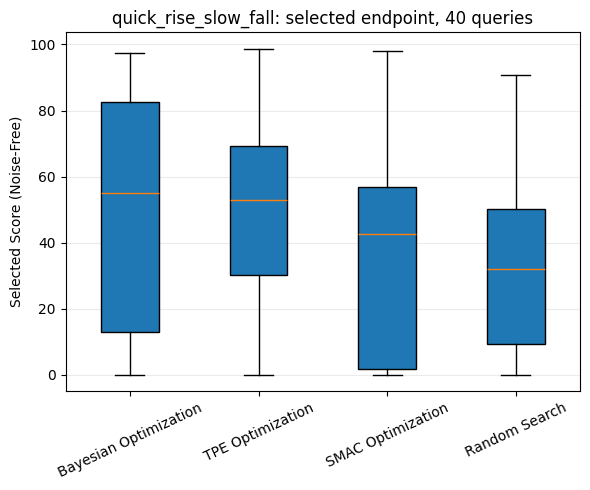

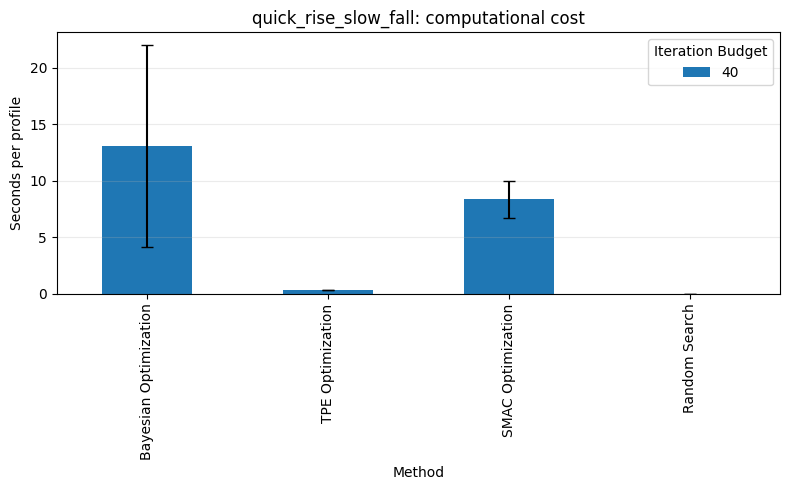

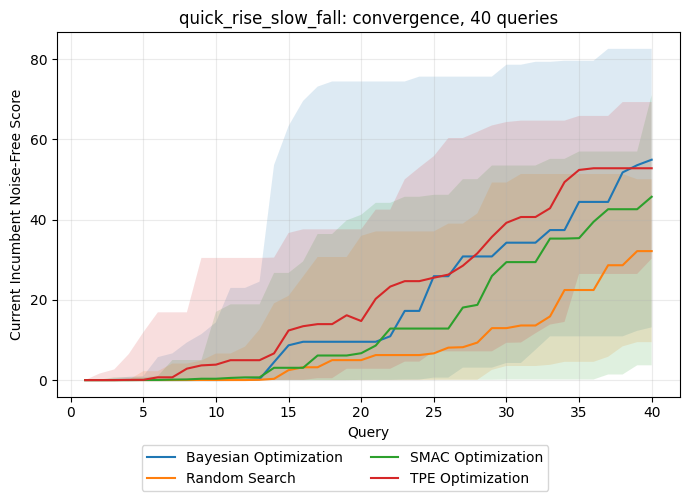

Primary endpoint: Selected Score (Noise-Free). The noisy observed maximum is excluded from the primary analysis.

--- Descriptive statistics, regret, and tolerance probability ---


,Iteration Budget,Method,N Profiles,Mean Score,SD Score,Median Score,IQR Score,Mean Simple Regret,Median Simple Regret,P Regret <= Tolerance
0,40,Bayesian Optimization,40,50.200803,35.439273,54.939947,69.433257,42.963295,31.397598,0.150
1,40,TPE Optimization,40,51.124911,27.731093,52.808626,39.042566,42.039186,36.452478,0.100
2,40,SMAC Optimization,40,37.033945,33.218265,42.597513,55.316115,56.130152,50.637664,0.050
3,40,Random Search,40,32.494571,27.078103,32.153982,40.623421,60.669527,59.625094,0.025



--- Paired omnibus tests ---


,Iteration Budget,N Paired Profiles,Endpoint,Paired Permutation Range Statistic,Paired Permutation P Value,Friedman Statistic,Friedman P Value,Welch F Statistic,Welch DF 1,Welch DF 2,Welch P Value
0,40,40,Selected Score (Noise-Free),18.630341,0.037848,14.01,0.002892,4.033601,3,86.185929,0.009803



--- Paired sign-flip tests with Holm correction ---


...


--- Common-random-number audit ---
Full row-level audit is returned as 'common_random_number_df'.


,Iteration Budget,N Tested Groups,N Passed Groups,N Failed Groups,Overall Status
0,40,1600,1600,0,PASS



--- Convergence trajectory summary ---
Full query-by-query convergence summary is returned as 'trajectory_summary_df'.


,Surface Family,Method,Iteration Budget,N Queries,First Query,Final Query,First Median Score,Final Median Score,Final Q25,Final Q75,Median Improvement
0,quick_rise_slow_fall,Bayesian Optimization,40,40,1,40,0.002396,54.939947,13.144617,82.577874,54.937551
1,quick_rise_slow_fall,Random Search,40,40,1,40,0.000998,32.153982,9.457004,50.080426,32.152985
2,quick_rise_slow_fall,SMAC Optimization,40,40,1,40,0.000645,45.703498,3.683793,71.056092,45.702853
3,quick_rise_slow_fall,TPE Optimization,40,40,1,40,0.000501,52.808626,30.267481,69.310047,52.808126


,Iteration Budget,Method,N Profiles,Mean Score,SD Score,Median Score,IQR Score,Mean Simple Regret,Median Simple Regret,P Regret <= Tolerance
0,40,Bayesian Optimization,40,50.200803,35.439273,54.939947,69.433257,42.963295,31.397598,0.150
1,40,TPE Optimization,40,51.124911,27.731093,52.808626,39.042566,42.039186,36.452478,0.100
2,40,SMAC Optimization,40,37.033945,33.218265,42.597513,55.316115,56.130152,50.637664,0.050
3,40,Random Search,40,32.494571,27.078103,32.153982,40.623421,60.669527,59.625094,0.025


In [ ]:
baseline_family_outputs = run_and_export_family(
    family=baseline_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=True,
)

analyze_family_results(baseline_family_outputs)["summary_df"]

In [ ]:
symmetric_family_outputs = run_and_export_family(
    family=symmetric_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(symmetric_family_outputs)["summary_df"]

In [ ]:
slow_rise_quick_fall_family_outputs = run_and_export_family(
    family=slow_rise_quick_fall_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(slow_rise_quick_fall_family_outputs)["summary_df"]

In [ ]:
three_optima_family_outputs = run_and_export_family(
    family=three_optima_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(three_optima_family_outputs)["summary_df"]

In [ ]:
broad_peaks_family_outputs = run_and_export_family(
    family=broad_peaks_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(broad_peaks_family_outputs)["summary_df"]

In [ ]:
sharp_peaks_family_outputs = run_and_export_family(
    family=sharp_peaks_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(sharp_peaks_family_outputs)["summary_df"]

In [ ]:
hetero_peaks_family_outputs = run_and_export_family(
    family=heteroscedastic_noise_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(hetero_peaks_family_outputs)["summary_df"]

In [ ]:
heavy_tailed_noise_family_outputs = run_and_export_family(
    family=heavy_tailed_noise_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(heavy_tailed_noise_family_outputs)["summary_df"]

In [ ]:
unique_parameter_interaction_family_outputs = run_and_export_family(
    family=unique_parameter_interaction_family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

analyze_family_results(unique_parameter_interaction_family_outputs)["summary_df"]

In [ ]:
sensitivity_methods = [
    "Bayesian Optimization",
    "TPE Optimization",
    "SMAC Optimization",
    "Random Search",
]
sensitivity_regret_tolerance = 0.05
sensitivity_n_permutations = 20000
sensitivity_n_bootstrap = 10000
sensitivity_random_seed = 10001
include_symmetric_smoke_test = False

sensitivity_family_specs = [
    {
        "family_name": "quick_rise_slow_fall",
        "outputs_var": "quick_rise_slow_fall_family_outputs",
    },
    {
        "family_name": "slow_rise_quick_fall",
        "outputs_var": "slow_rise_quick_fall_family_outputs",
    },
    {
        "family_name": "3optima",
        "outputs_var": "three_optima_family_outputs",
    },
    {
        "family_name": "broad_optima",
        "outputs_var": "broad_peaks_family_outputs",
    },
    {
        "family_name": "sharp_optima",
        "outputs_var": "sharp_peaks_family_outputs",
    },
    {
        "family_name": "heteroscedastic_noise",
        "outputs_var": "hetero_peaks_family_outputs",
    },
    {
        "family_name": "heavy_tailed_noise",
        "outputs_var": "heavy_tailed_noise_family_outputs",
    },
    {
        "family_name": "unique_parameter_interaction",
        "outputs_var": "unique_parameter_interaction_family_outputs",
    },
]
if include_symmetric_smoke_test:
    sensitivity_family_specs.insert(
        1,
        {
            "family_name": "symmetric",
            "outputs_var": "symmetric_family_outputs",
        },
    )

required_sensitivity_variables = []
for sensitivity_spec in sensitivity_family_specs:
    required_sensitivity_variables.extend(
        variable_name
        for variable_name in [
            sensitivity_spec.get("results_var"),
            sensitivity_spec.get("convergence_var"),
            sensitivity_spec.get("outputs_var"),
        ]
        if variable_name is not None
    )
missing_sensitivity_variables = [
    variable_name
    for variable_name in required_sensitivity_variables
    if variable_name not in globals()
]
if missing_sensitivity_variables:
    raise RuntimeError(
        "Run the formal family simulation cells before the final sensitivity "
        "analysis. Missing variables: "
        + ", ".join(missing_sensitivity_variables)
    )


def _concat_sensitivity_frames(data, label):
    if isinstance(data, pd.DataFrame):
        return data.copy()
    if isinstance(data, (list, tuple)) and data:
        if not all(isinstance(frame, pd.DataFrame) for frame in data):
            raise TypeError(f"Every item in {label} must be a pandas DataFrame.")
        return pd.concat([frame.copy() for frame in data], ignore_index=True)
    raise TypeError(f"{label} must be a non-empty DataFrame or list of DataFrames.")


def _unique_budget_values(frame):
    if frame.empty or "Iteration Budget" not in frame.columns:
        return []
    values = pd.to_numeric(frame["Iteration Budget"], errors="coerce")
    if values.isna().any():
        raise ValueError("Iteration Budget contains missing or non-numeric values.")
    return sorted(values.astype(int).unique().tolist())


def _get_sensitivity_sources(sensitivity_spec):
    if "outputs_var" in sensitivity_spec:
        outputs = globals()[sensitivity_spec["outputs_var"]]
        if not isinstance(outputs, dict):
            raise TypeError(
                f"{sensitivity_spec['outputs_var']} must be the dictionary "
                "returned by run_and_export_family."
            )
        results_data = outputs.get("results_df")
        if results_data is None:
            results_data = outputs.get("family_test")
        convergence_data = outputs.get("convergence_df")
        if convergence_data is None:
            convergence_data = outputs.get("family_convergence")
    else:
        results_data = globals()[sensitivity_spec["results_var"]]
        convergence_data = globals()[sensitivity_spec["convergence_var"]]
    return results_data, convergence_data


def _normalize_sensitivity_family(family_name, results_data, convergence_data):
    results_df = _concat_sensitivity_frames(results_data, f"{family_name} results")
    convergence_df = _concat_sensitivity_frames(
        convergence_data,
        f"{family_name} convergence",
    )

    for frame, label in [
        (results_df, f"{family_name} results"),
        (convergence_df, f"{family_name} convergence"),
    ]:
        if "Surface Family" not in frame.columns:
            frame["Surface Family"] = family_name
        frame["Surface Family"] = frame["Surface Family"].astype(str)
        observed_families = set(frame["Surface Family"].unique())
        if observed_families != {family_name}:
            raise ValueError(
                f"{label} contains {sorted(observed_families)}, expected "
                f"only {family_name!r}."
            )

    if "Seed" not in results_df.columns:
        raise ValueError(f"{family_name} results must contain a Seed column.")
    results_df["Profile ID"] = (
        family_name + "::" + results_df["Seed"].astype(str)
    )

    profile_seed_column = (
        "Profile Seed" if "Profile Seed" in convergence_df.columns else "Seed"
    )
    if profile_seed_column in convergence_df.columns:
        convergence_df["Profile ID"] = (
            family_name + "::" + convergence_df[profile_seed_column].astype(str)
        )
    elif "Profile ID" in convergence_df.columns:
        convergence_df["Profile ID"] = convergence_df["Profile ID"].astype(str)
    else:
        raise ValueError(
            f"{family_name} convergence must contain Profile ID, Profile Seed, or Seed."
        )

    budget_values = sorted(
        set(_unique_budget_values(results_df))
        | set(_unique_budget_values(convergence_df))
    )
    if len(budget_values) != 1:
        raise ValueError(
            f"{family_name} must have exactly one iteration budget; found "
            f"{budget_values}."
        )
    iteration_budget = budget_values[0]
    results_df["Iteration Budget"] = iteration_budget
    convergence_df["Iteration Budget"] = iteration_budget

    required_result_columns = {
        "Method",
        "Best Possible Score",
        "Selected Score (Noise-Free)",
    }
    missing_columns = required_result_columns.difference(results_df.columns)
    if missing_columns:
        raise ValueError(
            f"{family_name} results are missing {sorted(missing_columns)}."
        )
    results_df["Method"] = results_df["Method"].astype(str)
    observed_methods = set(results_df["Method"].unique())
    if observed_methods != set(sensitivity_methods):
        raise ValueError(
            f"{family_name} must contain exactly the four expected methods; "
            f"found {sorted(observed_methods)}."
        )

    for column in ["Best Possible Score", "Selected Score (Noise-Free)"]:
        results_df[column] = pd.to_numeric(results_df[column], errors="coerce")
    if results_df[["Best Possible Score", "Selected Score (Noise-Free)"]].isna().any().any():
        raise ValueError(f"{family_name} contains missing or non-numeric scores.")
    if not np.isfinite(
        results_df[["Best Possible Score", "Selected Score (Noise-Free)"]]
        .to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{family_name} contains non-finite scores.")
    if (results_df["Best Possible Score"] <= 0).any():
        raise ValueError(f"{family_name} has non-positive Best Possible Score values.")

    duplicate_keys = results_df.duplicated(
        subset=["Profile ID", "Iteration Budget", "Method"],
        keep=False,
    )
    if duplicate_keys.any():
        raise ValueError(
            f"{family_name} has duplicate profile-method-budget result rows."
        )
    profile_method_counts = results_df.groupby(
        ["Profile ID", "Iteration Budget"]
    )["Method"].nunique()
    if (profile_method_counts != len(sensitivity_methods)).any():
        raise ValueError(
            f"{family_name} contains incomplete paired profiles; every profile "
            "must have all four methods."
        )

    results_df["Simple Regret"] = (
        results_df["Best Possible Score"]
        - results_df["Selected Score (Noise-Free)"]
    )
    results_df["Normalized Regret"] = (
        results_df["Simple Regret"] / results_df["Best Possible Score"]
    )
    results_df["Normalized Regret (%)"] = 100 * results_df["Normalized Regret"]
    return results_df, convergence_df


normalized_family_results = []
normalized_family_convergence = []
for sensitivity_spec in sensitivity_family_specs:
    family_results, family_convergence = _normalize_sensitivity_family(
        sensitivity_spec["family_name"],
        *_get_sensitivity_sources(sensitivity_spec),
    )
    normalized_family_results.append(family_results)
    normalized_family_convergence.append(family_convergence)

sensitivity_results_df = pd.concat(normalized_family_results, ignore_index=True)
sensitivity_convergence_df = pd.concat(
    normalized_family_convergence,
    ignore_index=True,
)
sensitivity_results_df["Profile Rank"] = sensitivity_results_df.groupby(
    ["Profile ID", "Iteration Budget"]
)["Normalized Regret"].rank(method="average", ascending=True)


def _bootstrap_mean_ci(values, seed):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        mean_value = float(np.mean(values))
        return mean_value, mean_value
    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(
        values,
        size=(sensitivity_n_bootstrap, len(values)),
        replace=True,
    ).mean(axis=1)
    return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))


def _paired_sign_flip(values_a, values_b, seed):
    differences = np.asarray(values_a, dtype=float) - np.asarray(values_b, dtype=float)
    observed_difference = float(np.mean(differences))
    rng = np.random.default_rng(seed)
    signs = rng.choice(
        np.array([-1.0, 1.0]),
        size=(sensitivity_n_permutations, len(differences)),
    )
    permuted_means = np.mean(signs * differences, axis=1)
    p_value = (
        1
        + np.count_nonzero(np.abs(permuted_means) >= abs(observed_difference))
    ) / (sensitivity_n_permutations + 1)
    return differences, observed_difference, p_value


def _paired_range_permutation(wide, seed):
    values = wide.to_numpy(dtype=float)
    observed_statistic = float(np.ptp(values.mean(axis=0)))
    rng = np.random.default_rng(seed)
    permuted_statistics = np.empty(sensitivity_n_permutations)
    for permutation_index in range(sensitivity_n_permutations):
        permuted_values = np.array(
            [rng.permutation(profile_values) for profile_values in values]
        )
        permuted_statistics[permutation_index] = np.ptp(
            permuted_values.mean(axis=0)
        )
    p_value = (
        1
        + np.count_nonzero(permuted_statistics >= observed_statistic)
    ) / (sensitivity_n_permutations + 1)
    return observed_statistic, p_value


def _holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    valid = np.isfinite(p_values)
    if valid.any():
        adjusted[valid] = multipletests(p_values[valid], method="holm")[1]
    return adjusted


family_method_summary_rows = []
for group_index, (group_key, group) in enumerate(
    sensitivity_results_df.groupby(
        ["Iteration Budget", "Surface Family", "Method"],
        sort=True,
    )
):
    iteration_budget, family_name, method = group_key
    regret_values = group["Normalized Regret (%)"].to_numpy(dtype=float)
    ci_low, ci_high = _bootstrap_mean_ci(
        regret_values,
        sensitivity_random_seed + group_index,
    )
    family_method_summary_rows.append(
        {
            "Iteration Budget": iteration_budget,
            "Surface Family": family_name,
            "Method": method,
            "N Profiles": len(group),
            "Mean Normalized Regret (%)": np.mean(regret_values),
            "95% CI Low (%)": ci_low,
            "95% CI High (%)": ci_high,
            "Median Normalized Regret (%)": np.median(regret_values),
            "Q25 Normalized Regret (%)": np.quantile(regret_values, 0.25),
            "Q75 Normalized Regret (%)": np.quantile(regret_values, 0.75),
            "P Regret <= 5%": np.mean(
                group["Normalized Regret"] <= sensitivity_regret_tolerance
            ),
            "Mean Profile Rank": group["Profile Rank"].mean(),
            "P Best Method": np.mean(group["Profile Rank"] == 1),
            "Mean Seconds": (
                group["Sec To Compute"].mean()
                if "Sec To Compute" in group.columns
                else np.nan
            ),
        }
    )

sensitivity_family_method_df = pd.DataFrame(family_method_summary_rows)
sensitivity_family_method_df["Family Mean Regret Rank"] = (
    sensitivity_family_method_df.groupby(
        ["Iteration Budget", "Surface Family"]
    )["Mean Normalized Regret (%)"].rank(method="average", ascending=True)
)
sensitivity_family_method_matrix_df = (
    sensitivity_family_method_df.pivot(
        index=["Iteration Budget", "Surface Family"],
        columns="Method",
        values="Mean Normalized Regret (%)",
    )
    .reindex(columns=sensitivity_methods)
    .reset_index()
    .rename_axis(None, axis=1)
)

family_winner_rows = []
for group_key, group in sensitivity_family_method_df.groupby(
    ["Iteration Budget", "Surface Family"],
    sort=True,
):
    iteration_budget, family_name = group_key
    best_value = group["Mean Normalized Regret (%)"].min()
    winners = group[np.isclose(group["Mean Normalized Regret (%)"], best_value)][
        "Method"
    ].tolist()
    family_winner_rows.append(
        {
            "Iteration Budget": iteration_budget,
            "Surface Family": family_name,
            "Best Method(s)": "; ".join(winners),
            "Best Mean Normalized Regret (%)": best_value,
            "N Methods Tied": len(winners),
        }
    )
sensitivity_family_winners_df = pd.DataFrame(family_winner_rows)

overall_summary_rows = []
for budget_index, (iteration_budget, budget_frame) in enumerate(
    sensitivity_results_df.groupby("Iteration Budget", sort=True)
):
    budget_family_summary = sensitivity_family_method_df[
        sensitivity_family_method_df["Iteration Budget"] == iteration_budget
    ]
    budget_winner_rows = sensitivity_family_winners_df[
        sensitivity_family_winners_df["Iteration Budget"] == iteration_budget
    ]
    winner_counts = {
        method: int(
            budget_winner_rows["Best Method(s)"].map(
                lambda winner_text: method in {
                    winner.strip()
                    for winner in winner_text.split(";")
                }
            ).sum()
        )
        for method in sensitivity_methods
    }
    for method_index, method in enumerate(sensitivity_methods):
        method_frame = budget_frame[budget_frame["Method"] == method]
        profile_regrets = method_frame["Normalized Regret (%)"].to_numpy(dtype=float)
        family_means = budget_family_summary.loc[
            budget_family_summary["Method"] == method,
            "Mean Normalized Regret (%)",
        ].to_numpy(dtype=float)
        family_tolerance = budget_family_summary.loc[
            budget_family_summary["Method"] == method,
            "P Regret <= 5%",
        ].to_numpy(dtype=float)
        family_ranks = budget_family_summary.loc[
            budget_family_summary["Method"] == method,
            "Family Mean Regret Rank",
        ].to_numpy(dtype=float)
        profile_ci_low, profile_ci_high = _bootstrap_mean_ci(
            profile_regrets,
            sensitivity_random_seed + 1000 + budget_index * 100 + method_index,
        )
        family_ci_low, family_ci_high = _bootstrap_mean_ci(
            family_means,
            sensitivity_random_seed + 2000 + budget_index * 100 + method_index,
        )
        overall_summary_rows.append(
            {
                "Iteration Budget": iteration_budget,
                "Method": method,
                "N Profiles": len(profile_regrets),
                "N Families": len(family_means),
                "Profile-Weighted Mean Regret (%)": np.mean(profile_regrets),
                "Profile-Weighted 95% CI Low (%)": profile_ci_low,
                "Profile-Weighted 95% CI High (%)": profile_ci_high,
                "Profile-Weighted Median Regret (%)": np.median(profile_regrets),
                "Profile-Weighted P Regret <= 5%": np.mean(
                    method_frame["Normalized Regret"] <= sensitivity_regret_tolerance
                ),
                "Profile-Weighted Mean Rank": method_frame["Profile Rank"].mean(),
                "Profile-Weighted P Best Method": np.mean(
                    method_frame["Profile Rank"] == 1
                ),
                "Equal-Family Mean Regret (%)": np.mean(family_means),
                "Equal-Family 95% CI Low (%)": family_ci_low,
                "Equal-Family 95% CI High (%)": family_ci_high,
                "Equal-Family P Regret <= 5%": np.mean(family_tolerance),
                "Equal-Family Mean Rank": np.mean(family_ranks),
                "N Families Best": winner_counts[method],
                "Mean Seconds": (
                    method_frame["Sec To Compute"].mean()
                    if "Sec To Compute" in method_frame.columns
                    else np.nan
                ),
            }
        )
sensitivity_overall_summary_df = pd.DataFrame(overall_summary_rows)

sensitivity_global_omnibus_rows = []
sensitivity_global_pairwise_rows = []
sensitivity_family_interaction_rows = []
for budget_index, (iteration_budget, budget_frame) in enumerate(
    sensitivity_results_df.groupby("Iteration Budget", sort=True)
):
    wide = (
        budget_frame.pivot(
            index="Profile ID",
            columns="Method",
            values="Normalized Regret",
        )
        .reindex(columns=sensitivity_methods)
        .dropna()
    )
    if len(wide) < 2:
        continue
    friedman_statistic, friedman_p_value = stats.friedmanchisquare(
        *[wide[method].to_numpy(dtype=float) for method in sensitivity_methods]
    )
    permutation_statistic, permutation_p_value = _paired_range_permutation(
        wide,
        sensitivity_random_seed + 3000 + budget_index,
    )
    sensitivity_global_omnibus_rows.append(
        {
            "Iteration Budget": iteration_budget,
            "N Paired Profiles": len(wide),
            "N Families": budget_frame["Surface Family"].nunique(),
            "Endpoint": "Selected Score (Noise-Free), normalized regret",
            "Friedman Statistic": friedman_statistic,
            "Friedman P Value": friedman_p_value,
            "Kendall's W": friedman_statistic
            / (len(wide) * (len(sensitivity_methods) - 1)),
            "Paired Permutation Range Statistic": permutation_statistic,
            "Paired Permutation P Value": permutation_p_value,
        }
    )

    for pair_index, (method_a, method_b) in enumerate(
        itertools.combinations(sensitivity_methods, 2)
    ):
        differences, mean_difference, p_value = _paired_sign_flip(
            wide[method_a],
            wide[method_b],
            sensitivity_random_seed
            + 4000
            + budget_index * 100
            + pair_index,
        )
        ci_low, ci_high = _bootstrap_mean_ci(
            100 * differences,
            sensitivity_random_seed
            + 5000
            + budget_index * 100
            + pair_index,
        )
        difference_sd = np.std(differences, ddof=1)
        sensitivity_global_pairwise_rows.append(
            {
                "Iteration Budget": iteration_budget,
                "Method A": method_a,
                "Method B": method_b,
                "N Paired Profiles": len(differences),
                "Mean Regret Difference (A - B) (%)": 100 * mean_difference,
                "95% CI Low (%)": ci_low,
                "95% CI High (%)": ci_high,
                "Paired Effect Size dz": (
                    mean_difference / difference_sd
                    if difference_sd > 0
                    else np.nan
                ),
                "P Method A Lower Regret": np.mean(differences < 0),
                "Paired Sign-Flip P Value": p_value,
            }
        )

    for pair_index, (method_a, method_b) in enumerate(
        itertools.combinations(sensitivity_methods, 2)
    ):
        family_difference_arrays = []
        family_mean_differences = []
        for _, family_frame in budget_frame.groupby("Surface Family"):
            family_wide = (
                family_frame.pivot(
                    index="Profile ID",
                    columns="Method",
                    values="Normalized Regret",
                )
                .reindex(columns=sensitivity_methods)
                .dropna()
            )
            if len(family_wide) > 0:
                family_differences = (
                    family_wide[method_a].to_numpy(dtype=float)
                    - family_wide[method_b].to_numpy(dtype=float)
                )
                family_difference_arrays.append(family_differences)
                family_mean_differences.append(np.mean(family_differences))
        if len(family_difference_arrays) >= 2:
            try:
                heterogeneity_statistic, heterogeneity_p_value = stats.kruskal(
                    *family_difference_arrays
                )
            except ValueError:
                heterogeneity_statistic, heterogeneity_p_value = np.nan, np.nan
        else:
            heterogeneity_statistic, heterogeneity_p_value = np.nan, np.nan
        sensitivity_family_interaction_rows.append(
            {
                "Iteration Budget": iteration_budget,
                "Method A": method_a,
                "Method B": method_b,
                "N Families": len(family_difference_arrays),
                "Mean Family Contrast (A - B) (%)": 100
                * np.mean(family_mean_differences),
                "SD Family Contrast (%)": (
                    100 * np.std(family_mean_differences, ddof=1)
                    if len(family_mean_differences) > 1
                    else np.nan
                ),
                "Min Family Contrast (%)": 100 * np.min(family_mean_differences),
                "Max Family Contrast (%)": 100 * np.max(family_mean_differences),
                "Kruskal-Wallis H": heterogeneity_statistic,
                "Family Contrast Heterogeneity P Value": heterogeneity_p_value,
            }
        )

sensitivity_global_omnibus_df = pd.DataFrame(sensitivity_global_omnibus_rows)
sensitivity_global_pairwise_df = pd.DataFrame(sensitivity_global_pairwise_rows)
if not sensitivity_global_pairwise_df.empty:
    sensitivity_global_pairwise_df["Holm Adjusted P Value"] = np.nan
    for iteration_budget in sensitivity_global_pairwise_df["Iteration Budget"].unique():
        budget_mask = (
            sensitivity_global_pairwise_df["Iteration Budget"] == iteration_budget
        )
        sensitivity_global_pairwise_df.loc[budget_mask, "Holm Adjusted P Value"] = _holm_adjust(
            sensitivity_global_pairwise_df.loc[
                budget_mask,
                "Paired Sign-Flip P Value",
            ]
        )
sensitivity_family_interaction_df = pd.DataFrame(
    sensitivity_family_interaction_rows
)
if not sensitivity_family_interaction_df.empty:
    sensitivity_family_interaction_df["Holm Adjusted P Value"] = np.nan
    for iteration_budget in sensitivity_family_interaction_df["Iteration Budget"].unique():
        budget_mask = sensitivity_family_interaction_df["Iteration Budget"] == iteration_budget
        sensitivity_family_interaction_df.loc[
            budget_mask,
            "Holm Adjusted P Value",
        ] = _holm_adjust(
            sensitivity_family_interaction_df.loc[
                budget_mask,
                "Family Contrast Heterogeneity P Value",
            ]
        )

sensitivity_convergence_summary_df = pd.DataFrame()
sensitivity_convergence_compact_df = pd.DataFrame()
trajectory_score_column = "Normalized Regret So Far (%)"
if trajectory_score_column in sensitivity_convergence_df.columns and "Query" in sensitivity_convergence_df.columns:
    trajectory_group_columns = [
        "Surface Family",
        "Method",
        "Iteration Budget",
        "Query",
    ]
    sensitivity_convergence_summary_df = (
        sensitivity_convergence_df.groupby(trajectory_group_columns)[
            trajectory_score_column
        ]
        .agg(
            Median="median",
            Q25=lambda values: values.quantile(0.25),
            Q75=lambda values: values.quantile(0.75),
        )
        .reset_index()
    )
    profile_counts = (
        sensitivity_convergence_df.groupby(trajectory_group_columns)["Profile ID"]
        .nunique()
        .reset_index(name="N Profiles")
    )
    sensitivity_convergence_summary_df = sensitivity_convergence_summary_df.merge(
        profile_counts,
        on=trajectory_group_columns,
        how="left",
    )
    compact_rows = []
    compact_group_columns = [
        "Surface Family",
        "Method",
        "Iteration Budget",
    ]
    for group_key, group in sensitivity_convergence_summary_df.groupby(
        compact_group_columns,
        sort=True,
    ):
        ordered_group = group.sort_values("Query")
        ordered_group = ordered_group.dropna(subset=["Median"])
        if ordered_group.empty:
            continue
        first_row = ordered_group.iloc[0]
        final_row = ordered_group.iloc[-1]
        compact_rows.append(
            {
                **dict(zip(compact_group_columns, group_key)),
                "N Profiles": int(final_row["N Profiles"]),
                "N Queries": len(ordered_group),
                "First Query": first_row["Query"],
                "Final Query": final_row["Query"],
                "First Median Normalized Regret (%)": first_row["Median"],
                "Final Median Normalized Regret (%)": final_row["Median"],
                "Final Q25 (%)": final_row["Q25"],
                "Final Q75 (%)": final_row["Q75"],
                "Median Regret Improvement (%)": (
                    first_row["Median"] - final_row["Median"]
                ),
            }
        )
    sensitivity_convergence_compact_df = pd.DataFrame(compact_rows)

sensitivity_crn_audit_df = pd.DataFrame()
sensitivity_crn_summary_df = pd.DataFrame()
crn_columns = {
    "Profile ID",
    "Iteration Budget",
    "Query",
    "Method",
    "Evaluation Seed",
}
if crn_columns.issubset(sensitivity_convergence_df.columns):
    sensitivity_crn_audit_df = (
        sensitivity_convergence_df.groupby(
            ["Surface Family", "Profile ID", "Iteration Budget", "Query"]
        )
        .agg(
            N_Methods=("Method", "nunique"),
            N_Evaluation_Seeds=("Evaluation Seed", "nunique"),
        )
        .reset_index()
    )
    sensitivity_crn_audit_df["Uses Common Random Number"] = (
        (sensitivity_crn_audit_df["N_Methods"] == len(sensitivity_methods))
        & (sensitivity_crn_audit_df["N_Evaluation_Seeds"] == 1)
    )
    sensitivity_crn_summary_df = (
        sensitivity_crn_audit_df.groupby(["Surface Family", "Iteration Budget"])[
            "Uses Common Random Number"
        ]
        .agg(
            **{
                "N Tested Groups": "size",
                "N Passed Groups": "sum",
                "N Failed Groups": lambda values: (~values).sum(),
            }
        )
        .reset_index()
    )
    sensitivity_crn_summary_df["Overall Status"] = np.where(
        sensitivity_crn_summary_df["N Failed Groups"] == 0,
        "PASS",
        "FAIL",
    )

sensitivity_validation_rows = []
for family_name, family_frame in sensitivity_results_df.groupby(
    "Surface Family",
    sort=True,
):
    family_budgets = sorted(family_frame["Iteration Budget"].unique().tolist())
    sensitivity_validation_rows.append(
        {
            "Surface Family": family_name,
            "N Profiles": family_frame["Profile ID"].nunique(),
            "Iteration Budgets": ", ".join(str(value) for value in family_budgets),
            "N Methods": family_frame["Method"].nunique(),
            "Complete Paired Profiles": (
                family_frame.groupby(["Profile ID", "Iteration Budget"])["Method"]
                .nunique()
                .eq(len(sensitivity_methods))
                .all()
            ),
            "CRN Audit Status": (
                ", ".join(
                    sensitivity_crn_summary_df.loc[
                        sensitivity_crn_summary_df["Surface Family"] == family_name,
                        "Overall Status",
                    ].astype(str)
                )
                if not sensitivity_crn_summary_df.empty
                else "NOT AVAILABLE"
            ),
        }
    )
sensitivity_validation_df = pd.DataFrame(sensitivity_validation_rows)

sensitivity_export_frames = {
    "combined_sensitivity_profile_results.csv": sensitivity_results_df,
    "combined_sensitivity_convergence.csv": sensitivity_convergence_df,
    "sensitivity_family_method_summary.csv": sensitivity_family_method_df,
    "sensitivity_family_method_matrix.csv": sensitivity_family_method_matrix_df,
    "sensitivity_family_winners.csv": sensitivity_family_winners_df,
    "sensitivity_overall_summary.csv": sensitivity_overall_summary_df,
    "sensitivity_global_omnibus.csv": sensitivity_global_omnibus_df,
    "sensitivity_global_pairwise.csv": sensitivity_global_pairwise_df,
    "sensitivity_family_interaction.csv": sensitivity_family_interaction_df,
    "sensitivity_convergence_summary.csv": sensitivity_convergence_summary_df,
    "sensitivity_convergence_compact.csv": sensitivity_convergence_compact_df,
    "sensitivity_crn_audit.csv": sensitivity_crn_audit_df,
    "sensitivity_crn_summary.csv": sensitivity_crn_summary_df,
}
sensitivity_output_files = {}
for filename, frame in sensitivity_export_frames.items():
    output_path = Path(filename)
    frame.to_csv(output_path, index=False)
    sensitivity_output_files[filename] = str(output_path)

print(
    "Primary endpoint: Selected Score (Noise-Free), expressed as normalized "
    "regret; lower regret is better."
)
if sensitivity_results_df["Iteration Budget"].nunique() != 1:
    print(
        "The formal families use different iteration budgets. Results are "
        "reported separately by budget; rerun all formal families at one common "
        "budget before reporting a single pooled conclusion."
    )
if not include_symmetric_smoke_test:
    print(
        "The symmetric family is excluded because its cell is a generic smoke "
        "test rather than a formal sensitivity family."
    )
print("\n--- Sensitivity input validation ---")
display(sensitivity_validation_df)
print("\n--- Family-by-method effectiveness table ---")
display(sensitivity_family_method_df)
print("\n--- Mean normalized regret matrix (%) ---")
display(sensitivity_family_method_matrix_df)
print("\n--- Best method by family ---")
display(sensitivity_family_winners_df)
print("\n--- Overall profile-weighted and equal-family summary ---")
display(sensitivity_overall_summary_df)
print("\n--- Global paired omnibus tests, stratified by iteration budget ---")
display(sensitivity_global_omnibus_df)
print("\n--- Global paired post-hoc tests with Holm correction ---")
display(sensitivity_global_pairwise_df)
print("\n--- Family-by-method contrast heterogeneity ---")
display(sensitivity_family_interaction_df)
if not sensitivity_convergence_compact_df.empty:
    print("\n--- Compact cross-family convergence summary ---")
    display(sensitivity_convergence_compact_df)
if not sensitivity_crn_summary_df.empty:
    print("\n--- Compact cross-family common-random-number audit ---")
    display(sensitivity_crn_summary_df)
print(f"\nExported {len(sensitivity_output_files)} sensitivity-analysis CSV files.")

sensitivity_analysis_outputs = {
    "profile_results_df": sensitivity_results_df,
    "convergence_df": sensitivity_convergence_df,
    "family_method_summary_df": sensitivity_family_method_df,
    "family_method_matrix_df": sensitivity_family_method_matrix_df,
    "family_winners_df": sensitivity_family_winners_df,
    "overall_summary_df": sensitivity_overall_summary_df,
    "global_omnibus_df": sensitivity_global_omnibus_df,
    "global_pairwise_df": sensitivity_global_pairwise_df,
    "family_interaction_df": sensitivity_family_interaction_df,
    "convergence_summary_df": sensitivity_convergence_summary_df,
    "convergence_compact_df": sensitivity_convergence_compact_df,
    "crn_audit_df": sensitivity_crn_audit_df,
    "crn_summary_df": sensitivity_crn_summary_df,
    "validation_df": sensitivity_validation_df,
    "files": sensitivity_output_files,
}

RuntimeError: Run the formal family simulation cells before the final sensitivity analysis. Missing variables: quick_rise_slow_fall_family_outputs, slow_rise_quick_fall_family_outputs, three_optima_family_outputs, broad_peaks_family_outputs, sharp_peaks_family_outputs, hetero_peaks_family_outputs, heavy_tailed_noise_family_outputs, unique_parameter_interaction_family_outputs